<a href="https://colab.research.google.com/github/aishanee-sinha/Multi-Agent-Autonomous-Workforce-Assistant/blob/utkarsh_code%2Fmeeting_summarizer_demo/MSADI_Meeting_Summarizer_final_e2e_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cell 1 — Install dependencies (run if needed)

In [ ]:
# Cell 1 — Install dependencies (FIXED VERSION)
# This installs compatible versions that work together

# Uninstall any existing transformers to avoid conflicts
!pip uninstall -y transformers

# Install PyTorch 2.2.2 with CUDA 12.1 support
!pip install -q torch==2.2.2 torchvision==0.17.2 torchaudio==2.2.2 --index-url https://download.pytorch.org/whl/cu121

# Install compatible transformers version (4.41.0 works well with torch 2.2.2)
!pip install -q transformers==4.41.0

# Install other dependencies
!pip install -q --upgrade accelerate datasets rouge-score bert-score nltk tqdm scikit-learn matplotlib seaborn huggingface-hub python-dateutil dateparser icalendar

print("Installation complete!")

Found existing installation: transformers 4.57.1
Uninstalling transformers-4.57.1:
  Successfully uninstalled transformers-4.57.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bert-score 0.3.13 requires transformers>=3.0.0, which is not installed.
Installation complete!


# Cell 2 — Imports & NLTK setup

In [1]:
import os, json, math, re, random, time, textwrap, gc
from dataclasses import dataclass, asdict
from typing import List, Optional, Dict, Any

import numpy as np
import pandas as pd

import torch
from datasets import load_dataset
from tqdm.auto import tqdm

import nltk
# ↓↓↓ Add BOTH downloads to satisfy newer NLTK tokenizers
nltk.download('punkt', quiet=True)
try:
    nltk.download('punkt_tab', quiet=True)  # available on newer NLTK
except Exception:
    pass  # it's fine if it's not available in your version

from nltk.tokenize import sent_tokenize

import matplotlib.pyplot as plt

from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    pipeline,
)
from huggingface_hub import login as hf_login, whoami

print(f"Torch: {torch.__version__} | CUDA: {torch.cuda.is_available()} | Device count: {torch.cuda.device_count()}")

# quick self-test to avoid surprises later
_ = sent_tokenize("This is a sentence. And this is another one.")


/opt/conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Torch: 2.2.2+cu121 | CUDA: True | Device count: 1


# Cell 3 — Hugging Face login

In [2]:
# Cell 3 — Robust Hugging Face login for Colab (env -> secrets -> widget -> prompt)

import os
from huggingface_hub import login, whoami, notebook_login, HfFolder

def _colab_secret(name: str):
    # Works if you saved a secret in Colab: Runtime > Secrets > Add HF_TOKEN
    try:
        from google.colab import userdata  # type: ignore
        return userdata.get(name)
    except Exception:
        return None

token = os.getenv("HF_TOKEN") or _colab_secret("HF_TOKEN") or HfFolder.get_token()

if token:
    try:
        login(token=token, add_to_git_credential=True)
        me = whoami()
        print(f"HF auth as {me.get('name') or me.get('email')}")
    except Exception as e:
        print("Cached/env token failed, falling back to interactive login:", e)
        try:
            notebook_login()  # opens a UI in Colab to paste the token
            me = whoami()
            print(f"HF auth as {me.get('name') or me.get('email')}")
        except Exception:
            from getpass import getpass
            token = getpass("Paste your Hugging Face token (starts with 'hf_'): ")
            login(token=token, add_to_git_credential=True)
            me = whoami()
            print(f"HF auth as {me.get('name') or me.get('email')}")
else:
    # No token anywhere → ask the user
    try:
        notebook_login()
        me = whoami()
        print(f"HF auth as {me.get('name') or me.get('email')}")
    except Exception:
        from getpass import getpass
        token = getpass("Paste your Hugging Face token (starts with 'hf_'): ")
        login(token=token, add_to_git_credential=True)
        me = whoami()
        print(f"HF auth as {me.get('name') or me.get('email')}")


Token has not been saved to git credential helper.


Cannot authenticate through git-credential as no helper is defined on your machine.
You might have to re-authenticate when pushing to the Hugging Face Hub.
Run the following command in your terminal in case you want to set the 'store' credential helper as default.

git config --global credential.helper store

Read https://git-scm.com/book/en/v2/Git-Tools-Credential-Storage for more details.
HF auth as utkarsh9630


# Cell 4 — Config

In [3]:
# Cell 4 — Config (aligned with incremental/resume-safe Cell 11)

class Config:
    PROJECT_NAME = "AI-Powered Autonomous Workforce Assistants"
    MODULE_NAME  = "Meeting Summarizer Agent"

    # -----------------------------
    # Dataset
    # -----------------------------
    DATASET_REPO  = "knkarthick/AMI"   # AMI meeting transcripts
    USE_AMI       = True
    TOTAL_SAMPLES = 150                # cap for quick runs; increase for full set

    # Splits
    TRAIN_RATIO   = 0.7
    VAL_RATIO     = 0.15
    TEST_RATIO    = 0.15
    RANDOM_STATE  = 42

    # -----------------------------
    # Models (LLM-only)
    # Run one-at-a-time via EVAL_ONLY in Cell 11 if desired
    # -----------------------------
    MODELS = {
        "FLAN-T5-BASE":  "google/flan-t5-base",
        "FLAN-T5-LARGE": "google/flan-t5-large",
        "BART-CNN":      "facebook/bart-large-cnn",
        "PEGASUS-XSUM":  "google/pegasus-xsum",
        # Optional long-context (heavier):
        # "LED-BASE":    "allenai/led-base-16384",
    }

    # -----------------------------
    # Evaluation controls used by Cell 11
    # Set these at runtime as needed:
    #   - EVAL_ONLY = ["BART-CNN"]   # run just one model now
    #   - VAL_SAMPLE_CAP = 10        # quick debug pass
    #   - SKIP_IF_EXISTS = True      # skip models already evaluated
    # -----------------------------
    EVAL_ONLY      = None     # or ["BART-CNN"], ["FLAN-T5-LARGE"], etc.
    VAL_SAMPLE_CAP = None     # e.g., 10..30 for faster iteration; None = full VAL
    SKIP_IF_EXISTS = False    # True -> if artifacts exist, do not re-run that model

    # -----------------------------
    # Generation params (shared defaults)
    # -----------------------------
    GEN = dict(
        max_length=256,
        min_length=96,
        num_beams=4,
        length_penalty=1.0,
        no_repeat_ngram_size=3,
        do_sample=False,
        truncation=True,   # ensure tokenizer truncates long inputs
    )

    # -----------------------------
    # Prompting
    # -----------------------------
    USE_MEETING_PROMPT = True
    NUM_EXAMPLES       = 2

    # -----------------------------
    # IO (matches Cell 11 artifact paths)
    # -----------------------------
    OUTPUT_DIR  = "meeting_summarizer_output_final"
    RESULTS_DIR = os.path.join(OUTPUT_DIR, "results")
    GEN_DIR     = os.path.join(OUTPUT_DIR, "meetings")
    # Cell 11 will write:
    #   - per-model VAL samples → results/val_metrics__<MODEL>.csv
    #   - per-model VAL aggregate → results/val_agg__<MODEL>.json
    #   - combined ranking → results/llm_geval_val_model_ranking.csv
    #   - selected top-2 → results/selected_top2.json

    # -----------------------------
    # G-Eval weights
    # -----------------------------
    WTS = {
        "coherence":      0.20,
        "consistency":    0.25,
        "fluency":        0.10,
        "relevance":      0.25,
        "action_quality": 0.20,
    }

cfg = Config()
for p in [cfg.OUTPUT_DIR, cfg.RESULTS_DIR, cfg.GEN_DIR]:
    os.makedirs(p, exist_ok=True)

print("Config OK:", cfg.RESULTS_DIR)


Config OK: meeting_summarizer_output_final/results


# Cell 5 — Data structures for outputs

In [4]:
from dataclasses import dataclass, asdict
from typing import List, Optional

@dataclass
class ActionItem:
    owner: str
    task: str
    due_date: Optional[str] = None
    priority: str = "Medium"

@dataclass
class NextMeeting:
    scheduled: bool = False
    date: Optional[str] = None
    time: Optional[str] = None
    purpose: Optional[str] = None

@dataclass
class MeetingSummary:
    meeting_id: str
    date: Optional[str]
    overview: str
    key_points: List[str]
    decisions: List[str]
    action_items: List[ActionItem]
    next_meeting: Optional[NextMeeting]
    attendees: Optional[List[str]]

    def to_dict(self):
        d = asdict(self)
        d["action_items"] = [asdict(a) for a in self.action_items]
        d["next_meeting"] = asdict(self.next_meeting) if self.next_meeting else None
        return d


# Cell 6 — Load AMI and create splits (train/val/test)

In [5]:
random.seed(cfg.RANDOM_STATE)
np.random.seed(cfg.RANDOM_STATE)

print("Loading dataset…")
raw = load_dataset(cfg.DATASET_REPO)
# Use the first available split as the pool
split_name = list(raw.keys())[0]
pool = raw[split_name]
print("Total examples in pool:", len(pool))

# Optional subsample
if cfg.TOTAL_SAMPLES and len(pool) > cfg.TOTAL_SAMPLES:
    idxs = np.random.RandomState(cfg.RANDOM_STATE).choice(len(pool), cfg.TOTAL_SAMPLES, replace=False)
    pool = pool.select(sorted(idxs))
    print(f"Subsampled to {len(pool)} examples.")

TRANSCRIPT_KEYS = ["transcript", "text", "document", "content", "meeting_transcript", "article"]
ID_KEYS   = ["id", "meeting_id", "uid", "guid"]
DATE_KEYS = ["date", "meeting_date", "timestamp"]

def get_val(d: Dict[str, Any], keys: List[str], default=None):
    for k in keys:
        if k in d and d[k] is not None:
            return d[k]
    return default

def get_transcript(row: Dict[str, Any]) -> str:
    t = get_val(row, TRANSCRIPT_KEYS, None)
    if t is None and "utterances" in row and isinstance(row["utterances"], list):
        t = "\n".join(u.get("text", "") for u in row["utterances"]) or None
    if t is None and "words" in row and isinstance(row["words"], list):
        t = " ".join(row["words"]) or None
    if t is None:
        t = " ".join(str(v) for v in row.values() if isinstance(v, str))
    return t

indices = list(range(len(pool)))
rs = np.random.RandomState(cfg.RANDOM_STATE)
rs.shuffle(indices)

n = len(indices)
train_end = int(n * cfg.TRAIN_RATIO)
val_end   = int(n * (cfg.TRAIN_RATIO + cfg.VAL_RATIO))

train_idx = indices[:train_end]
val_idx   = indices[train_end:val_end]
test_idx  = indices[val_end:]

splits_manifest = {"train": train_idx, "val": val_idx, "test": test_idx}
with open(os.path.join(cfg.OUTPUT_DIR, "dataset_splits.json"), "w") as f:
    json.dump(splits_manifest, f, indent=2)

print(f"Split sizes — train: {len(train_idx)} | val: {len(val_idx)} | test: {len(test_idx)}")


Loading dataset…
Total examples in pool: 209
Subsampled to 150 examples.
Split sizes — train: 105 | val: 22 | test: 23


In [9]:
# Figure 1 — Sample Raw Transcript Snippet
# - Chooses one item from your split (default: VAL)
# - Grabs the RAW transcript field directly from the dataset row
# - Smart-trims to a clean snippet end (sentence/line boundary) to avoid ragged cutoffs

import re

# ---------- config knobs ----------
SPLIT_FOR_SNIPPET = "val"   # "val" | "train" | "test"
SPLIT_INDEX       = 0       # which item within that split to show
SNIPPET_CHARS     = 1200    # target length for the printed snippet
# ----------------------------------

def _pick_split_indices():
    if SPLIT_FOR_SNIPPET.lower() == "train" and "train_idx" in globals():
        return train_idx
    if SPLIT_FOR_SNIPPET.lower() == "test" and "test_idx" in globals():
        return test_idx
    if "val_idx" in globals():
        return val_idx
    raise RuntimeError("No split indices found. Make sure dataset splits were created earlier.")

def _detect_transcript_key(row: dict):
    # try common raw fields first; fall back to any long text-like field if present
    candidates = [
        "transcript", "text", "dialogue", "dialog", "content", "meeting_transcript",
        "body", "raw_text"
    ]
    for k in candidates:
        if k in row and isinstance(row[k], str) and row[k].strip():
            return k
    # final fallback: choose the longest string field in row (as a best-effort raw)
    str_fields = [(k, v) for k, v in row.items() if isinstance(v, str) and len(v.strip()) > 0]
    if str_fields:
        # longest by length
        str_fields.sort(key=lambda kv: len(kv[1]), reverse=True)
        return str_fields[0][0]
    return None

def _smart_trim(txt: str, max_chars: int) -> str:
    """Trim at a natural boundary (sentence end / newline) not exceeding max_chars."""
    if len(txt) <= max_chars:
        return txt.strip()
    chunk = txt[:max_chars+1]
    # prefer last sentence boundary
    m = re.search(r'(?s)(.*?)([.!?]["\')\]]?\s|\n\s*\n|$)', chunk[::-1])
    if m:
        # reverse trick: we searched in reversed string; compute cut index
        cut_in_rev = m.end()  # end in reversed chunk
        cut = max_chars + 1 - cut_in_rev
        trimmed = txt[:max(1, cut)].rstrip()
        if len(trimmed) > 50:  # avoid over-trimming
            return trimmed
    # fallback: cut at last newline or space
    for sep in ["\n", " "]:
        p = chunk.rfind(sep)
        if p > 50:
            return chunk[:p].rstrip()
    return chunk.rstrip()

def _get_safe(row: dict, keys):
    for k in keys:
        if k in row and isinstance(row[k], (str, int, float)):
            return row[k]
    return None

# pick the row
_indices = _pick_split_indices()
if not _indices:
    raise RuntimeError(f"No indices for split '{SPLIT_FOR_SNIPPET}'.")
gidx = _indices[min(max(0, SPLIT_INDEX), len(_indices)-1)]
row  = pool[gidx]  # assumes 'pool' is your list/dataset of rows

# try to resolve meeting id / date using your helper if present
meeting_id = None
meeting_date = None
if "get_val" in globals() and "ID_KEYS" in globals():
    try:
        meeting_id = get_val(row, ID_KEYS, None)
    except Exception:
        pass
if "get_val" in globals() and "DATE_KEYS" in globals():
    try:
        meeting_date = get_val(row, DATE_KEYS, None)
    except Exception:
        pass
# fallback if not available
meeting_id   = meeting_id or _get_safe(row, ["id", "meeting_id", "doc_id", "file"])
meeting_date = meeting_date or _get_safe(row, ["date", "timestamp"])

# fetch RAW transcript from the row
raw_key = _detect_transcript_key(row)
if not raw_key:
    # last resort: use the helper (may be cleaned) to avoid empty output
    if "get_transcript" in globals():
        raw_text = get_transcript(row)
        raw_key = "(fallback:get_transcript)"
    else:
        raise RuntimeError("Could not find a transcript-like field in the row, and no get_transcript() available.")
else:
    raw_text = row[raw_key]

# trim and print
snippet = _smart_trim(raw_text, SNIPPET_CHARS)

print("\n" + "="*78)
print("Sample Raw Transcript Snippet")
print("="*78)
print(f"Split        : {SPLIT_FOR_SNIPPET.upper()}  |  Local index: {SPLIT_INDEX}  |  Global index: {gidx}")
print(f"Meeting ID   : {meeting_id}")
print(f"Date         : {meeting_date}")
print(f"Raw field    : {raw_key}")
print(f"Total length : {len(raw_text):,} chars")
print("-"*78)
print(snippet)
print("-"*78)
print(f"[End of snippet ~{len(snippet):,} chars]")



Sample Raw Transcript Snippet
Split        : VAL  |  Local index: 0  |  Global index: 6
Meeting ID   : 2
Date         : None
Raw field    : dialogue
Total length : 32,198 chars
------------------------------------------------------------------------------
Speaker A: Okay. Okay. Mm-hmm. Wow. So, sorry I was just gonna say, what was the question for this? Or is are you coming on to that? Okay. So these percentages are are what? Hmm. Mm, mm. Mm-hmm. Mm-hmm. Yep, sure, that's cool, um Yeah. I can turn my computer quickly if that's okay. Um, yep. Okay, and then what do I press, F_ eight? Oh right. Okay, cool. Oh. Yeah. No signal. Okay. Cool. Okay and then how do I press the the big one, to get it on to the big F_ five and I press that again to get it off as well do I? Okay, so um I'm the interface design designer, User Interface Designer sorry, uh I'm concerned with um w what effect the apparatus should have on the user and um I'm I'm also I want to point out that our motto, put the fashio

In [8]:
# Figure 2 — Sample Raw Record JSON / Tabular View
# - Picks one item from the chosen split (default: VAL)
# - Prints a PRETTY-PRINTED JSON of the raw record (long fields safely truncated)
# - Shows a compact TABULAR view (key, type, length, preview)
# - Highlights detected transcript field (name + length)

import json, re
from collections import OrderedDict
import pandas as pd

# ------------- config knobs -------------
SPLIT_FOR_SAMPLE  = "val"   # "val" | "train" | "test"
SPLIT_INDEX       = 0       # which item within that split to show
MAX_STR_PREVIEW   = 160     # truncate long strings for display
MAX_LIST_PREVIEW  = 5       # items to preview from lists
MAX_DICT_KEYS     = 10      # keys to preview from nested dicts (for JSON)
# ---------------------------------------

def _pick_split_indices():
    if SPLIT_FOR_SAMPLE.lower() == "train" and "train_idx" in globals():
        return train_idx
    if SPLIT_FOR_SAMPLE.lower() == "test" and "test_idx" in globals():
        return test_idx
    if "val_idx" in globals():
        return val_idx
    raise RuntimeError("No split indices found. Make sure dataset splits were created earlier.")

def _detect_transcript_key(row: dict):
    # Try common raw fields first; fall back to the longest textual field
    candidates = [
        "transcript", "text", "dialogue", "dialog", "content", "meeting_transcript",
        "body", "raw_text"
    ]
    for k in candidates:
        if k in row and isinstance(row[k], str) and row[k].strip():
            return k
    # fallback: choose the longest string field
    str_fields = [(k, v) for k, v in row.items() if isinstance(v, str) and len(v.strip()) > 0]
    if str_fields:
        str_fields.sort(key=lambda kv: len(kv[1]), reverse=True)
        return str_fields[0][0]
    return None

def _shorten(s: str, limit: int) -> str:
    if s is None:
        return ""
    if len(s) <= limit:
        return s
    # try to end on a boundary
    chunk = s[:limit]
    p = max(chunk.rfind("\n"), chunk.rfind(". "), chunk.rfind(" "))
    if p >= 40:
        chunk = chunk[:p]
    return chunk.rstrip() + f" … [len={len(s):,}]"

def _stringify(value, limit_chars=160):
    if isinstance(value, str):
        return _shorten(value, limit_chars)
    if isinstance(value, (int, float, bool)) or value is None:
        return str(value)
    if isinstance(value, list):
        preview = ", ".join(_stringify(v, limit_chars=40) for v in value[:MAX_LIST_PREVIEW])
        extra = "" if len(value) <= MAX_LIST_PREVIEW else f", … (+{len(value)-MAX_LIST_PREVIEW} more)"
        return f"[{len(value)} items] {preview}{extra}"
    if isinstance(value, dict):
        keys = list(value.keys())[:MAX_DICT_KEYS]
        extra = "" if len(value) <= MAX_DICT_KEYS else f", … (+{len(value)-MAX_DICT_KEYS} more keys)"
        return "{ " + ", ".join(keys) + (" }" if not extra else f"{extra} }}")
    # fallback
    try:
        return _shorten(json.dumps(value, ensure_ascii=False), limit_chars)
    except Exception:
        return _shorten(str(value), limit_chars)

def _json_sanitized(d: dict) -> dict:
    """Return a JSON-safe, truncated copy for pretty printing."""
    def _clip(v):
        if isinstance(v, str):
            return _shorten(v, MAX_STR_PREVIEW)
        if isinstance(v, list):
            return [_clip(x) for x in v[:MAX_LIST_PREVIEW]] + (["…"] if len(v) > MAX_LIST_PREVIEW else [])
        if isinstance(v, dict):
            out = OrderedDict()
            for i, k in enumerate(v.keys()):
                if i >= MAX_DICT_KEYS:
                    out["…"] = f"+{len(v)-MAX_DICT_KEYS} more keys"
                    break
                out[k] = _clip(v[k])
            return out
        return v
    out = OrderedDict()
    for k in d.keys():
        out[k] = _clip(d[k])
    return out

def _get_safe(row: dict, keys):
    for k in keys:
        if k in row and isinstance(row[k], (str, int, float)):
            return row[k]
    return None

# ---- pick the sample row from the chosen split ----
_indices = _pick_split_indices()
if not _indices:
    raise RuntimeError(f"No indices for split '{SPLIT_FOR_SAMPLE}'.")
gidx = _indices[min(max(0, SPLIT_INDEX), len(_indices)-1)]
row_raw = pool[gidx]

# ensure dict-like
try:
    row = dict(row_raw)
except Exception:
    row = row_raw  # already dict-ish

# meeting id and date
meeting_id = None
meeting_date = None
if "get_val" in globals() and "ID_KEYS" in globals():
    try: meeting_id = get_val(row, ID_KEYS, None)
    except Exception: pass
if "get_val" in globals() and "DATE_KEYS" in globals():
    try: meeting_date = get_val(row, DATE_KEYS, None)
    except Exception: pass
meeting_id   = meeting_id or _get_safe(row, ["id", "meeting_id", "doc_id", "file"])
meeting_date = meeting_date or _get_safe(row, ["date", "timestamp"])

# transcript field info
tkey = _detect_transcript_key(row)
tlen = len(row[tkey]) if (tkey and isinstance(row.get(tkey), str)) else None

# ----------- JSON view (sanitized) -----------
print("\n" + "="*88)
print("Sample Raw Record (JSON view)")
print("="*88)
header = {
    "split": SPLIT_FOR_SAMPLE.upper(),
    "local_index": SPLIT_INDEX,
    "global_index": gidx,
    "meeting_id": meeting_id,
    "date": meeting_date,
    "transcript_field": tkey,
    "transcript_length_chars": tlen,
}
print(json.dumps(header, ensure_ascii=False, indent=2))

print("\n--- Raw record (truncated for display) ---")
print(json.dumps(_json_sanitized(row), ensure_ascii=False, indent=2))

# ----------- Tabular view -----------
# Build a simple key/value table with type + length/preview
records = []
for k, v in row.items():
    v_type = type(v).__name__
    v_len = (len(v) if isinstance(v, (str, list, dict)) else None)
    v_preview = _stringify(v, limit_chars=MAX_STR_PREVIEW)
    records.append({"key": k, "type": v_type, "len": v_len, "preview": v_preview})

df = pd.DataFrame(records).sort_values("key").reset_index(drop=True)

print("\n" + "-"*88)
print("Tabular view (key / type / len / preview):")
print("-"*88)
display(df)

# Helpful reminder for your report:
print("\n[Tip] For the report, screenshot either the JSON header + a few JSON keys, or the top rows of the table above.")



Sample Raw Record (JSON view)
{
  "split": "VAL",
  "local_index": 0,
  "global_index": 6,
  "meeting_id": 2,
  "date": null,
  "transcript_field": "dialogue",
  "transcript_length_chars": 32198
}

--- Raw record (truncated for display) ---
{
  "id": 2,
  "dialogue": "Speaker A: Okay. Okay. Mm-hmm. Wow. So, sorry I was just gonna say, what was the question for this? Or is are you coming on to that? Okay. So these percentages … [len=32,198]",
  "summary": "well w what I didn't actually realise it was that the uh this is for a specific television . So the all in one idea goes out the window . now , it was function … [len=8,457]"
}

----------------------------------------------------------------------------------------
Tabular view (key / type / len / preview):
----------------------------------------------------------------------------------------


,key,type,len,preview
0,dialogue,str,32198.0,"Speaker A: Okay. Okay. Mm-hmm. Wow. So, sorry ..."
1,id,int,NaN,2
2,summary,str,8457.0,well w what I didn't actually realise it was t...



[Tip] For the report, screenshot either the JSON header + a few JSON keys, or the top rows of the table above.


In [11]:
# Figure 3 — Before/After Cleaning Example (STRONG version so differences are obvious)

import re, unicodedata, json
import pandas as pd

# ---------------- config ----------------
SPLIT_FOR_SAMPLE  = "val"   # "val" | "train" | "test"
SPLIT_INDEX       = 0       # which item within that split to show
RAW_SNIPPET_CHARS = 700
CLN_SNIPPET_CHARS = 700
# ----------------------------------------

def _pick_split_indices():
    if SPLIT_FOR_SAMPLE.lower() == "train" and "train_idx" in globals():
        return train_idx
    if SPLIT_FOR_SAMPLE.lower() == "test" and "test_idx" in globals():
        return test_idx
    if "val_idx" in globals():
        return val_idx
    raise RuntimeError("No split indices found. Make sure dataset splits were created earlier.")

def _detect_transcript_key(row: dict):
    # Prefer common transcript keys; fallback to the longest string field
    candidates = [
        "transcript", "text", "dialogue", "dialog", "content", "meeting_transcript",
        "body", "raw_text"
    ]
    for k in candidates:
        if k in row and isinstance(row[k], str) and row[k].strip():
            return k
    str_fields = [(k, v) for k, v in row.items() if isinstance(v, str) and v.strip()]
    if str_fields:
        str_fields.sort(key=lambda kv: len(kv[1]), reverse=True)
        return str_fields[0][0]
    return None

def _smart_trim(txt: str, max_chars: int) -> str:
    if len(txt) <= max_chars:
        return txt.strip()
    chunk = txt[:max_chars+1]
    # try to end on sentence or blank line
    m = re.search(r'(?s)^(.{200,}?)(?:[.!?]["\')\]]?\s|\n\s*\n)', chunk)
    if m:
        return m.group(1).strip()
    # fallback: last whitespace
    p = max(chunk.rfind("\n"), chunk.rfind(" "))
    return (chunk[:p] if p > 80 else chunk[:max_chars]).rstrip()

def _get_safe(row: dict, keys):
    for k in keys:
        if k in row and isinstance(row[k], (str, int, float)):
            return row[k]
    return None

# ---------------- strong cleaner & counters ----------------
_URL_RE                 = re.compile(r'https?://\S+|www\.\S+', re.I)
_HTML_TAG_RE            = re.compile(r'<[^>]+>')
_BRACKET_TS_RE          = re.compile(r'\[\s*\d{1,2}:\d{2}(?::\d{2})?\s*\]')   # [00:03], [1:02:03]
_BARE_TS_RE             = re.compile(r'(?<!\d)(\d{1,2}:\d{2}(?::\d{2})?)(?!\d)')  # 00:03 or 1:02:03
_STAGE_NOTES_RE         = re.compile(r'\((?:[^)]*?(?:inaudible|laughter|noise|crosstalk|music|applause|cough|sigh|phone rings|background|pause)[^)]*?)\)', re.I)
_SPEAKER_LABEL_FIX_RE   = re.compile(r'^\s*([A-Za-z][\w .-]{0,30})\s*:\s*', re.M)
_FILLERS_RE             = re.compile(r'\b(um+|uh+|er+|ah+|hmm+|mm+|mmm+|uh[-\s]?huh+|mm[-\s]?hmm+|you know|kind of|sort of)\b[,\.\s]*', re.I)
_REPEAT_SHORT_WORDS_RE  = re.compile(r'\b(\w{2,4})(?:\s+\1){1,5}\b', re.I)  # ok ok -> ok; are are -> are
_STUTTER_DASH_RE        = re.compile(r'\b((\w)-\2-){1,3}(\w+)\b')           # w-w-what -> what
_MULTI_PUNCT_RE         = re.compile(r'([,.!?;:])\1{1,}')                   # "!!" -> "!"
_MULTISPACE_RE          = re.compile(r'[ \t]{2,}')
_MULTI_NL_RE            = re.compile(r'\n{3,}')

def clean_strong(text: str):
    """Return cleaned text + counters dict of what changed."""
    c = {
        "urls":0, "html":0, "timestamps_bracket":0, "timestamps_bare":0,
        "stage_notes":0, "fillers":0, "repeats":0, "stutters":0, "multi_punct":0,
        "spaces":0, "newlines":0, "speaker_labels_normalized":0
    }
    if not text:
        return text, c

    t = unicodedata.normalize("NFKC", text)

    def subn(rx, repl, s):
        out, n = rx.subn(repl, s)
        return out, n

    t, n = _HTML_TAG_RE.subn(' ', t);               c["html"] += n
    t, n = _URL_RE.subn(' ', t);                    c["urls"] += n
    t, n = _BRACKET_TS_RE.subn(' ', t);             c["timestamps_bracket"] += n
    t, n = _BARE_TS_RE.subn(' ', t);                c["timestamps_bare"] += n
    t, n = _STAGE_NOTES_RE.subn(' ', t);            c["stage_notes"] += n

    # normalize speaker labels spacing: "Speaker A :" -> "Speaker A:"
    def _fix_lab(m):
        c["speaker_labels_normalized"] += 1
        return m.group(1).strip() + ": "
    t = _SPEAKER_LABEL_FIX_RE.sub(_fix_lab, t)

    t, n = _FILLERS_RE.subn(' ', t);                c["fillers"] += n
    t, n = _REPEAT_SHORT_WORDS_RE.subn(r'\1', t);   c["repeats"] += n
    t, n = _STUTTER_DASH_RE.subn(r'\3', t);         c["stutters"] += n
    t, n = _MULTI_PUNCT_RE.subn(r'\1', t);          c["multi_punct"] += n

    # whitespace normalization
    t = t.replace('\r\n', '\n').replace('\r', '\n')
    t, n = _MULTISPACE_RE.subn(' ', t);             c["spaces"] += n
    t, n2 = _MULTI_NL_RE.subn('\n\n', t);           c["newlines"] += n2

    return t.strip(), c

# ---------------- pull a sample row ----------------
_indices = _pick_split_indices()
gidx = _indices[min(max(0, SPLIT_INDEX), len(_indices)-1)]
row  = pool[gidx]  # assumes your dataset rows are addressable via 'pool'

meeting_id = None
meeting_date = None
if "get_val" in globals() and "ID_KEYS" in globals():
    try: meeting_id = get_val(row, ID_KEYS, None)
    except: pass
if "get_val" in globals() and "DATE_KEYS" in globals():
    try: meeting_date = get_val(row, DATE_KEYS, None)
    except: pass
meeting_id   = meeting_id or _get_safe(row, ["id", "meeting_id", "doc_id", "file"])
meeting_date = meeting_date or _get_safe(row, ["date", "timestamp"])

raw_key = _detect_transcript_key(row)
if not raw_key:
    # fallback to helper if available
    if "get_transcript" in globals():
        raw_text = get_transcript(row)
        raw_key  = "(fallback:get_transcript)"
    else:
        raise RuntimeError("Could not locate a transcript-like field and get_transcript() is not available.")
else:
    raw_text = row[raw_key]

# ---------------- clean & report ----------------
clean_text, counts = clean_strong(raw_text)

len_raw = len(raw_text or "")
len_cln = len(clean_text or "")
reduction_pct = (1 - (len_cln / len_raw)) * 100 if len_raw else 0.0

raw_snip = _smart_trim(raw_text, RAW_SNIPPET_CHARS)
cln_snip = _smart_trim(clean_text, CLN_SNIPPET_CHARS)

print("\n" + "="*88)
print("Figure 3 — Before/After Cleaning Example (STRONG)")
print("="*88)
print(f"Split: {SPLIT_FOR_SAMPLE.upper()} | Local idx: {SPLIT_INDEX} | Global idx: {gidx}")
print(f"Meeting ID: {meeting_id} | Date: {meeting_date}")
print(f"Transcript field: {raw_key}")
print(f"Length (raw):   {len_raw:,} chars")
print(f"Length (clean): {len_cln:,} chars  |  Δ ≈ {reduction_pct:.1f}%")

print("\n[Cleaning counters]")
print(json.dumps(counts, indent=2))

print("\n" + "-"*88)
print("[RAW snippet]")
print(raw_snip)
print("-"*88)
print("[CLEANED snippet]")
print(cln_snip)
print("-"*88)

# Side-by-side first lines preview for screenshots in your report
def _first_lines(s, n=6):
    lines = (s or "").splitlines()
    return "\n".join(lines[:n])

df_preview = pd.DataFrame({
    "raw (first lines)":     [_first_lines(raw_text, n=6)],
    "cleaned (first lines)": [_first_lines(clean_text, n=6)],
})
display(df_preview)



Figure 3 — Before/After Cleaning Example (STRONG)
Split: VAL | Local idx: 0 | Global idx: 6
Meeting ID: 2 | Date: None
Transcript field: dialogue
Length (raw):   32,198 chars
Length (clean): 30,050 chars  |  Δ ≈ 6.7%

[Cleaning counters]
{
  "urls": 0,
  "html": 0,
  "timestamps_bracket": 0,
  "timestamps_bare": 0,
  "stage_notes": 0,
  "fillers": 491,
  "repeats": 45,
  "stutters": 0,
  "multi_punct": 0,
  "spaces": 403,
  "newlines": 0,
  "speaker_labels_normalized": 4
}

----------------------------------------------------------------------------------------
[RAW snippet]
Speaker A: Okay. Okay. Mm-hmm. Wow. So, sorry I was just gonna say, what was the question for this? Or is are you coming on to that? Okay. So these percentages are are what? Hmm. Mm, mm. Mm-hmm. Mm-hmm
----------------------------------------------------------------------------------------
[CLEANED snippet]
Speaker A: Okay. Okay. - Wow. So, sorry I was just gonna say, what was the question for this? Or is are you 

,raw (first lines),cleaned (first lines)
0,"Speaker A: Okay. Okay. Mm-hmm. Wow. So, sorry ...","Speaker A: Okay. Okay. - Wow. So, sorry I was ..."



Figure 4 — Distribution of Transcript Lengths (Raw vs Cleaned) — STRONG
Scope: ALL | Meetings counted: 150

[Raw lengths     ] {'count': 150, 'min': 7854, 'p25': 18989.5, 'median': 26294.0, 'p75': 32890.0, 'p95': 39593.7, 'max': 45592, 'mean': 26100.1, 'std': 9177.4}
[Cleaned lengths ] {'count': 150, 'min': 7454, 'p25': 18270.2, 'median': 25099.0, 'p75': 31106.8, 'p95': 37580.9, 'max': 43703, 'mean': 24653.2, 'std': 8710.1}

Mean reduction ≈ 5.6% | Median ≈ 5.5%
[Saved] meeting_summarizer_output_final/results/fig_transcript_length_dist_STRONG.png


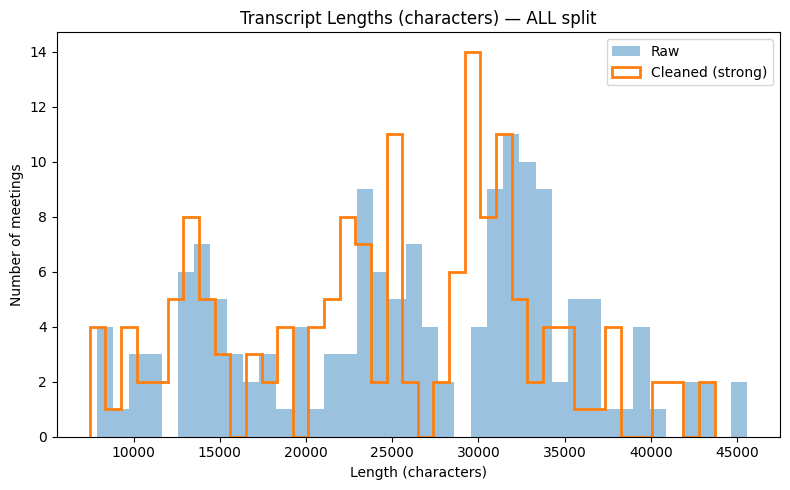

[Saved] meeting_summarizer_output_final/results/fig_transcript_shrink_percent_STRONG.png


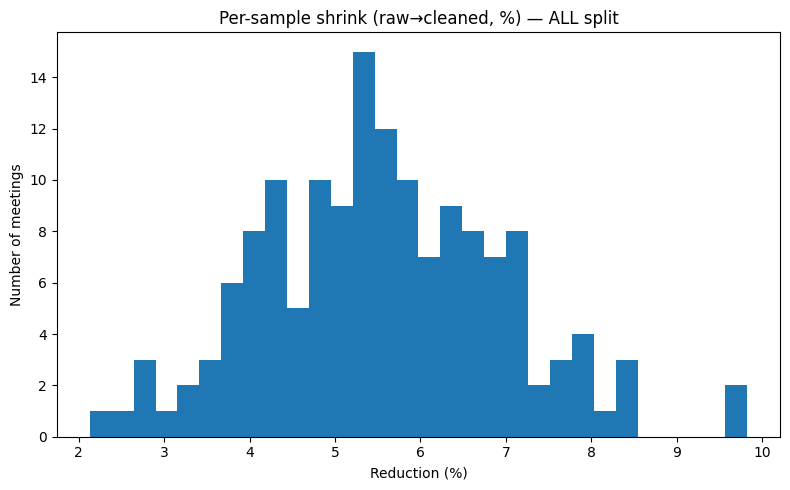

In [14]:
# Figure 4 — Distribution of Transcript Lengths (Raw vs Cleaned) — STRONG variant
# - Uses strong cleaner to make differences visible
# - Adds a 2nd plot: per-sample % reduction (raw→cleaned)

import re, unicodedata, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------- config -----------------------
SPLIT_SCOPE   = "all"     # "val" | "train" | "test" | "all"
SAMPLE_CAP    = None      # e.g., 250; None = all
BINS          = 40
SAVE_PNG      = True
PNG_PATH1     = os.path.join(cfg.RESULTS_DIR, "fig_transcript_length_dist_STRONG.png")
PNG_PATH2     = os.path.join(cfg.RESULTS_DIR, "fig_transcript_shrink_percent_STRONG.png")
# ------------------------------------------------------

def _indices_for_scope(scope: str):
    scope = (scope or "").lower()
    if scope == "train" and "train_idx" in globals(): return list(train_idx)
    if scope == "val"   and "val_idx"   in globals(): return list(val_idx)
    if scope == "test"  and "test_idx"  in globals(): return list(test_idx)
    seen, out = set(), []
    for name in ["train_idx","val_idx","test_idx"]:
        if name in globals():
            for i in list(globals()[name]):
                if i not in seen:
                    out.append(i); seen.add(i)
    return out if out else list(range(len(pool)))

def _detect_transcript_key(row: dict):
    for k in ["transcript","text","dialogue","dialog","content","meeting_transcript","body","raw_text"]:
        if k in row and isinstance(row[k], str) and row[k].strip():
            return k
    sf = [(k,v) for k,v in row.items() if isinstance(v,str) and v.strip()]
    if sf:
        sf.sort(key=lambda kv: len(kv[1]), reverse=True)
        return sf[0][0]
    return None

# -------- strong cleaner (clearly visible differences) --------
_URL_RE                 = re.compile(r'https?://\S+|www\.\S+', re.I)
_HTML_TAG_RE            = re.compile(r'<[^>]+>')
_BRACKET_TS_RE          = re.compile(r'\[\s*\d{1,2}:\d{2}(?::\d{2})?\s*\]')   # [00:03], [1:02:03]
_BARE_TS_RE             = re.compile(r'(?<!\d)(\d{1,2}:\d{2}(?::\d{2})?)(?!\d)')  # 00:03 or 1:02:03
_STAGE_NOTES_RE         = re.compile(r'\((?:[^)]*?(?:inaudible|laughter|noise|crosstalk|music|applause|background|pause|cough|sigh)[^)]*?)\)', re.I)
_SPEAKER_FIX_RE         = re.compile(r'^\s*([A-Za-z][\w .-]{0,30})\s*:\s*', re.M)
_FILLERS_RE             = re.compile(r'\b(um+|uh+|er+|ah+|hmm+|mm+|mmm+|uh[-\s]?huh+|mm[-\s]?hmm+|you know|kind of|sort of)\b[,\.\s]*', re.I)
_REPEAT_SHORT_WORDS_RE  = re.compile(r'\b(\w{2,4})(?:\s+\1){1,5}\b', re.I)
_STUTTER_DASH_RE        = re.compile(r'\b((\w)-\2-){1,3}(\w+)\b')
_MULTIPUNCT_RE          = re.compile(r'([,.!?;:])\1{1,}')
_MULTISPACE_RE          = re.compile(r'[ \t]{2,}')
_MULTI_NL_RE            = re.compile(r'\n{3,}')

def clean_strong(text: str) -> str:
    if not text: return text
    t = unicodedata.normalize("NFKC", text)
    t = _HTML_TAG_RE.sub(' ', t)
    t = _URL_RE.sub(' ', t)
    t = _BRACKET_TS_RE.sub(' ', t)
    t = _BARE_TS_RE.sub(' ', t)
    t = _STAGE_NOTES_RE.sub(' ', t)
    t = _SPEAKER_FIX_RE.sub(lambda m: m.group(1).strip() + ": ", t)
    t = _FILLERS_RE.sub(' ', t)
    t = _REPEAT_SHORT_WORDS_RE.sub(r'\1', t)
    t = _STUTTER_DASH_RE.sub(r'\3', t)
    t = _MULTIPUNCT_RE.sub(r'\1', t)
    t = t.replace('\r\n','\n').replace('\r','\n')
    t = _MULTISPACE_RE.sub(' ', t)
    t = _MULTI_NL_RE.sub('\n\n', t)
    return t.strip()

# ---------------- collect lengths ----------------
idxs = _indices_for_scope(SPLIT_SCOPE)
if SAMPLE_CAP: idxs = idxs[:SAMPLE_CAP]

raw_lengths, clean_lengths, shrink_pct = [], [], []
used = []
for gi in idxs:
    row = pool[gi]
    key = _detect_transcript_key(row)
    if key:
        raw = row.get(key, "")
    elif "get_transcript" in globals():
        raw = get_transcript(row)
    else:
        continue
    if not isinstance(raw, str) or not raw.strip():
        continue
    cln = clean_strong(raw)
    rlen, clen = len(raw), len(cln)
    raw_lengths.append(rlen)
    clean_lengths.append(clen)
    shrink_pct.append(0.0 if rlen == 0 else 100.0 * (1.0 - (clen / rlen)))
    used.append(gi)

if not used:
    raise RuntimeError("No usable transcripts found. Check dataset/scope.")

raw_lengths   = np.array(raw_lengths)
clean_lengths = np.array(clean_lengths)
shrink_pct    = np.array(shrink_pct)

def _summary(arr):
    return {
        "count": int(arr.size),
        "min":   int(np.min(arr)),
        "p25":   float(np.percentile(arr, 25)),
        "median":float(np.median(arr)),
        "p75":   float(np.percentile(arr, 75)),
        "p95":   float(np.percentile(arr, 95)),
        "max":   int(np.max(arr)),
        "mean":  float(np.mean(arr)),
        "std":   float(np.std(arr)),
    }

sr = _summary(raw_lengths); sc = _summary(clean_lengths)
print("\n" + "="*88)
print("Figure 4 — Distribution of Transcript Lengths (Raw vs Cleaned) — STRONG")
print("="*88)
print(f"Scope: {SPLIT_SCOPE.upper()} | Meetings counted: {len(used)}")
print("\n[Raw lengths     ]", {k: (round(v,1) if isinstance(v,float) else v) for k,v in sr.items()})
print("[Cleaned lengths ]", {k: (round(v,1) if isinstance(v,float) else v) for k,v in sc.items()})
print(f"\nMean reduction ≈ {np.mean(shrink_pct):.1f}% | Median ≈ {np.median(shrink_pct):.1f}%")

# ---------------- plot 1: lengths overlay ----------------
plt.figure(figsize=(8,5))
plt.hist(raw_lengths,   bins=BINS, alpha=0.45, label="Raw")
plt.hist(clean_lengths, bins=BINS, histtype='step', linewidth=2, label="Cleaned (strong)")
plt.title(f"Transcript Lengths (characters) — {SPLIT_SCOPE.upper()} split")
plt.xlabel("Length (characters)"); plt.ylabel("Number of meetings")
plt.legend(loc="upper right"); plt.tight_layout()
if SAVE_PNG:
    os.makedirs(cfg.RESULTS_DIR, exist_ok=True)
    plt.savefig(PNG_PATH1, dpi=150)
    print(f"[Saved] {PNG_PATH1}")
plt.show()

# ---------------- plot 2: shrink percentage ----------------
plt.figure(figsize=(8,5))
plt.hist(shrink_pct, bins=30)
plt.title(f"Per-sample shrink (raw→cleaned, %) — {SPLIT_SCOPE.upper()} split")
plt.xlabel("Reduction (%)"); plt.ylabel("Number of meetings")
plt.tight_layout()
if SAVE_PNG:
    plt.savefig(PNG_PATH2, dpi=150)
    print(f"[Saved] {PNG_PATH2}")
plt.show()


# Cell 7 — Few-shot examples & prompt builders

In [18]:
FEW_SHOT_EXAMPLES = [
    {
        "transcript": "Alice: Kickoff…\nBob: Timeline…\nCarol: Risks…",
        "summary": (
            "Overview: Project kickoff covering timeline, risks, and owners.\n\n"
            "Key Points:\n- Timeline milestones outlined for Q4.\n- Identified risks around API readiness.\n\n"
            "Decisions:\n- Adopt weekly sync on Tuesdays.\n\n"
            "Action Items:\n- [Alice] — Draft project plan — Due: Oct 10\n- [Bob] — Confirm API availability with vendor — Due: Oct 7\n\n"
            "Next Meeting: Scheduled — Date: Oct 3 — Time: 10:00 — Purpose: Weekly status\n"
        ),
    },
    {
        "transcript": "Dana: Metrics…\nEve: Deployment…",
        "summary": (
            "Overview: Review of metrics and deployment plan.\n\n"
            "Key Points:\n- Conversion up 3%.\n- Canary deploy planned.\n\n"
            "Decisions:\n- Proceed with canary in region us-west.\n\n"
            "Action Items:\n- [Eve] — Prepare rollout doc — Due: Oct 12\n\n"
            "Next Meeting: Not scheduled\n"
        ),
    },
]

PROMPT_INSTRUCTIONS = (
    "You are a meeting summarization assistant. Read the transcript and produce a structured summary with the following sections in order:\n"
    "1) Overview (2-4 sentences).\n"
    "2) Key Points (3-7 bullet points).\n"
    "3) Decisions (bullet points; write 'None' if no explicit decisions).\n"
    "4) Action Items (format each as: [Owner] — Task — Due: <date or 'None'>).\n"
    "5) Next Meeting (either 'Not scheduled' or 'Scheduled — Date: <date> — Time: <time> — Purpose: <purpose>').\n"
    "Be faithful to the transcript. Keep it concise and specific."
)

def build_meeting_prompt(transcript: str, examples: Optional[List[Dict[str, str]]] = None) -> str:
    parts = [PROMPT_INSTRUCTIONS]
    if examples:
        for ex in examples[: cfg.NUM_EXAMPLES]:
            parts.append("\nExample Transcript:\n" + ex["transcript"])
            parts.append("Example Summary:\n" + ex["summary"])
    parts.append("\nTranscript:\n" + transcript.strip())
    parts.append("\nNow write the structured summary strictly following the format.")
    return "\n\n".join(parts)

def build_instruction_prompt(transcript: str) -> str:
    return (
        PROMPT_INSTRUCTIONS
        + "\n\nTranscript:\n" + transcript.strip()
        + "\n\nStructured Summary:"
    )


In [19]:
# Figure 5 — Prompt Template Screenshot (uses your exact builders)

import re, textwrap, os

# ------------ knobs ------------
SPLIT_FOR_SAMPLE  = "val"   # "val" | "train" | "test"
SPLIT_INDEX       = 0       # which item in that split
TRANSCRIPT_CHARS  = 1200    # how much of the transcript to include
SHOW_SKELETON     = True    # also show compact template skeletons
SAVE_TXT          = False   # True ⇒ save the two prompts as .txt in cfg.RESULTS_DIR
# -------------------------------

def _pick_split_indices():
    if SPLIT_FOR_SAMPLE.lower() == "train" and "train_idx" in globals(): return train_idx
    if SPLIT_FOR_SAMPLE.lower() == "test"  and "test_idx"  in globals(): return test_idx
    if "val_idx" in globals(): return val_idx
    raise RuntimeError("No split indices found. Run the dataset splits first.")

def _detect_transcript_key(row: dict):
    for k in ["transcript","text","dialogue","dialog","content","meeting_transcript","body","raw_text"]:
        if k in row and isinstance(row[k], str) and row[k].strip():
            return k
    s = [(k,v) for k,v in row.items() if isinstance(v,str) and v.strip()]
    if s:
        s.sort(key=lambda kv: len(kv[1]), reverse=True)
        return s[0][0]
    return None

def _smart_trim(txt: str, max_chars: int) -> str:
    if len(txt) <= max_chars:
        return txt.strip()
    chunk = txt[:max_chars+1]
    m = re.search(r'(?s)^(.{200,}?)(?:[.!?]["\')\]]?\s|\n\s*\n)', chunk)  # end on sentence/blank if possible
    if m: return m.group(1).strip() + " …"
    p = max(chunk.rfind("\n"), chunk.rfind(" "))
    return (chunk[:p] if p > 80 else chunk[:max_chars]).rstrip() + " …"

# --- fetch a sample transcript ---
_indices = _pick_split_indices()
gidx = _indices[min(max(0, SPLIT_INDEX), len(_indices)-1)]
row  = pool[gidx]

key = _detect_transcript_key(row)
if key:
    transcript_raw = row.get(key, "")
elif "get_transcript" in globals():
    transcript_raw = get_transcript(row)
else:
    raise RuntimeError("Could not find a transcript-like field and get_transcript() is not available.")

transcript_snip = _smart_trim(transcript_raw, TRANSCRIPT_CHARS)

# --- build prompts using YOUR functions exactly ---
prompt_instruction = build_instruction_prompt(transcript_snip)
prompt_meeting     = build_meeting_prompt(transcript_snip, FEW_SHOT_EXAMPLES)

print("\n" + "="*88)
print("Prompt Template (Instruction-only)")
print("="*88)
print(prompt_instruction)

print("\n" + "="*88)
print("Prompt Template (Meeting + Few-shot)")
print("="*88)
print(prompt_meeting)

# --- optional skeletons for a cleaner screenshot (no long transcript) ---
if SHOW_SKELETON:
    skeleton_instruction = (
        PROMPT_INSTRUCTIONS
        + "\n\nTranscript:\n<TRANSCRIPT_SNIPPET>\n\nStructured Summary:"
    ).strip()

    # show how the few-shot blocks are embedded by your builder
    fewshot_note = f"<Include up to {cfg.NUM_EXAMPLES} few-shot Example Transcript/Example Summary blocks>"
    skeleton_meeting = (
        PROMPT_INSTRUCTIONS
        + f"\n\n{fewshot_note}\n\nTranscript:\n<TRANSCRIPT_SNIPPET>\n\nNow write the structured summary strictly following the format."
    ).strip()

    print("\n" + "="*88)
    print("Template Skeletons (compact, for screenshot)")
    print("="*88)
    print("[Instruction skeleton]\n" + skeleton_instruction)
    print("\n[Meeting skeleton]\n" + skeleton_meeting)

# --- optional: save .txt files for your records/screenshots ---
if SAVE_TXT:
    os.makedirs(cfg.RESULTS_DIR, exist_ok=True)
    p1 = os.path.join(cfg.RESULTS_DIR, "fig5_prompt_instruction.txt")
    p2 = os.path.join(cfg.RESULTS_DIR, "fig5_prompt_meeting_fewshot.txt")
    with open(p1, "w") as f: f.write(prompt_instruction)
    with open(p2, "w") as f: f.write(prompt_meeting)
    print(f"\n[Saved]\n - {p1}\n - {p2}")



Prompt Template (Instruction-only)
You are a meeting summarization assistant. Read the transcript and produce a structured summary with the following sections in order:
1) Overview (2-4 sentences).
2) Key Points (3-7 bullet points).
3) Decisions (bullet points; write 'None' if no explicit decisions).
4) Action Items (format each as: [Owner] — Task — Due: <date or 'None'>).
5) Next Meeting (either 'Not scheduled' or 'Scheduled — Date: <date> — Time: <time> — Purpose: <purpose>').
Be faithful to the transcript. Keep it concise and specific.

Transcript:
Speaker A: Okay. Okay. Mm-hmm. Wow. So, sorry I was just gonna say, what was the question for this? Or is are you coming on to that? Okay. So these percentages are are what? Hmm. Mm, mm. Mm-hmm. Mm-hmm …

Structured Summary:

Prompt Template (Meeting + Few-shot)
You are a meeting summarization assistant. Read the transcript and produce a structured summary with the following sections in order:
1) Overview (2-4 sentences).
2) Key Points (

In [20]:
# Table — Example Split Manifest Rows
# - Samples N rows from each split (train/val/test)
# - Extracts meeting_id/date (if available), lengths, word count, speaker count, and a short preview
# - Saves a CSV (optional) and displays a compact table for the report

import re, unicodedata, os
import pandas as pd

# ------------------- knobs -------------------
SAMPLES_PER_SPLIT = 3          # how many rows from each split
PREVIEW_CHARS     = 120        # size of the preview text column
SAVE_CSV          = True       # write to cfg.RESULTS_DIR
CSV_PATH          = os.path.join(cfg.RESULTS_DIR, "example_split_manifest_rows.csv")
# ---------------------------------------------

def _detect_transcript_key(row: dict):
    for k in ["transcript","text","dialogue","dialog","content","meeting_transcript","body","raw_text"]:
        if k in row and isinstance(row[k], str) and row[k].strip():
            return k
    s = [(k,v) for k,v in row.items() if isinstance(v,str) and v.strip()]
    if s:
        s.sort(key=lambda kv: len(kv[1]), reverse=True)
        return s[0][0]
    return None

def _get_val_safe(row: dict, keys, default=None):
    if "get_val" in globals():
        try:
            return get_val(row, keys, default)
        except:
            pass
    # fallback scan
    for k in (keys if isinstance(keys, (list,tuple)) else [keys]):
        if k in row and isinstance(row[k], (str,int,float)):
            return row[k]
    return default

def _preview(txt: str, n=120):
    if not txt: return ""
    t = unicodedata.normalize("NFKC", txt).strip().replace("\r\n","\n").replace("\r","\n")
    if len(t) <= n: return t
    cut = t[:n+1]
    p = max(cut.rfind("\n"), cut.rfind(" "))
    return (cut[:p] if p > 40 else t[:n]) + " …"

_SPEAKER_LINE_RE = re.compile(r'(?m)^\s*([A-Za-z][\w .-]{0,30})\s*:\s+')

def _collect_split_rows(indices, split_name, n_take):
    rows = []
    if not indices:
        return rows
    take = min(n_take, len(indices))
    for j in range(take):
        gi = indices[j]
        row = pool[gi]
        # transcript
        key = _detect_transcript_key(row)
        if key:
            txt = row.get(key, "") or ""
        elif "get_transcript" in globals():
            txt = get_transcript(row) or ""
        else:
            continue
        if not isinstance(txt, str) or not txt.strip():
            continue

        meeting_id   = _get_val_safe(row, globals().get("ID_KEYS", ["meeting_id","id","doc_id","file"]), default=None)
        meeting_date = _get_val_safe(row, globals().get("DATE_KEYS", ["date","timestamp"]), default=None)

        rows.append({
            "split": split_name.upper(),
            "global_index": gi,
            "meeting_id": meeting_id,
            "date": meeting_date,
            "raw_chars": len(txt),
            "word_count": len(txt.split()),
            "speaker_count": len(_SPEAKER_LINE_RE.findall(txt)),
            "preview": _preview(txt, PREVIEW_CHARS),
        })
    return rows

manifest_records = []

# Collect per split (if they exist)
if "train_idx" in globals(): manifest_records += _collect_split_rows(list(train_idx), "train", SAMPLES_PER_SPLIT)
if "val_idx"   in globals(): manifest_records += _collect_split_rows(list(val_idx),   "val",   SAMPLES_PER_SPLIT)
if "test_idx"  in globals(): manifest_records += _collect_split_rows(list(test_idx),  "test",  SAMPLES_PER_SPLIT)

if not manifest_records:
    raise RuntimeError("No records collected. Make sure pool and split indices exist.")

df_manifest = pd.DataFrame(manifest_records, columns=[
    "split","global_index","meeting_id","date","raw_chars","word_count","speaker_count","preview"
])

# Nice sorting: TRAIN, VAL, TEST
_split_order = {"TRAIN":0,"VAL":1,"TEST":2}
df_manifest["__ord"] = df_manifest["split"].map(_split_order).fillna(9)
df_manifest = df_manifest.sort_values(["__ord","global_index"]).drop(columns="__ord").reset_index(drop=True)

# Display compact table (good for screenshot)
display(df_manifest)

,split,global_index,meeting_id,date,raw_chars,word_count,speaker_count,preview
0,TRAIN,18,85,None,25090,4680,4,Speaker A: Okay. Um welcome to our second meet...
1,TRAIN,73,2,None,32198,6198,4,"Speaker A: Okay. Okay. Mm-hmm. Wow. So, sorry ..."
2,TRAIN,118,134,None,13279,2516,4,"Speaker A: Hmm. Yes. Well. Oh my god, it's bet..."
3,VAL,6,2,None,32198,6198,4,"Speaker A: Okay. Okay. Mm-hmm. Wow. So, sorry ..."
4,VAL,100,133,None,14283,2789,4,Speaker A: Mm. Oh my name's Andrew I'm a I'm t...
5,VAL,112,99,None,30895,5876,4,"Speaker A: That's great. Alright, let me just ..."
6,TEST,21,119,None,38610,7526,4,Speaker A: One question. Send. Submit. Mm. Yea...
7,TEST,57,93,None,33186,6477,4,"Speaker A: Yeah. Oh really? Okay. Well. Uh, we..."
8,TEST,124,79,None,26259,5149,4,Speaker A: Yeah so uh following our decision t...



Record Counts by Stage


,Stage,Count
0,RAW,150
1,CLEANED,150
2,TRAIN,105
3,VAL,22
4,TEST,23


[Saved] meeting_summarizer_output_final/results/fig_counts_by_stage.png


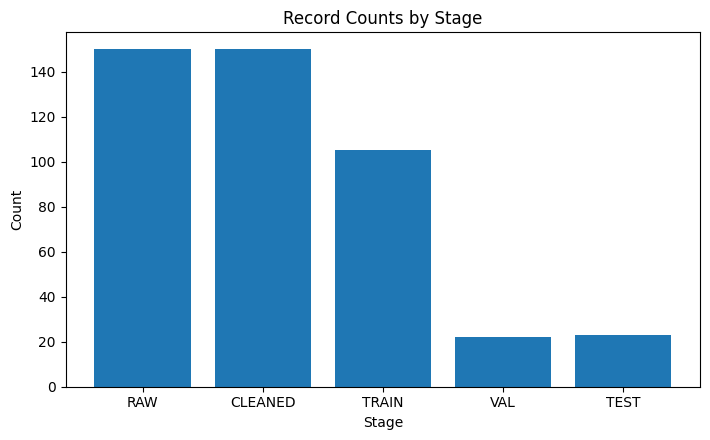

In [22]:
# Figure 7 — Bar Chart of Record Counts by Stage
# Counts: RAW (has transcript), CLEANED (after light cleaning), TRAIN, VAL, TEST.

import re, unicodedata, os
import pandas as pd
import matplotlib.pyplot as plt

# ---------- knobs ----------
MIN_NONEMPTY_CHARS = 20      # cleaned text must be longer than this to count
SAVE_PNG = True
PNG_PATH = os.path.join(cfg.RESULTS_DIR, "fig_counts_by_stage.png")
# ---------------------------

def _detect_transcript_key(row: dict):
    for k in ["transcript","text","dialogue","dialog","content","meeting_transcript","body","raw_text"]:
        if k in row and isinstance(row[k], str) and row[k].strip():
            return k
    s = [(k, v) for k, v in row.items() if isinstance(v, str) and v.strip()]
    if s:
        s.sort(key=lambda kv: len(kv[1]), reverse=True)
        return s[0][0]
    return None

# Use your cleaner if available, else a tiny fallback
def _fallback_clean(text: str) -> str:
    if not text: return text
    t = unicodedata.normalize("NFKC", text)
    t = re.sub(r'<[^>]+>', ' ', t)                                # HTML tags
    t = re.sub(r'https?://\S+|www\.\S+', ' ', t, flags=re.I)      # URLs
    t = re.sub(r'\[\s*\d{1,2}:\d{2}(?::\d{2})?\s*\]', ' ', t)     # [00:03]
    t = re.sub(r'^\s*([A-Za-z][\w .-]{0,30})\s*:\s*', r'\1: ', t, flags=re.M)
    t = t.replace("\r\n","\n").replace("\r","\n")
    t = re.sub(r'[ \t]{2,}', ' ', t)
    t = re.sub(r'\n{3,}', '\n\n', t)
    return t.strip()

def _clean(text: str) -> str:
    if "clean_moderate" in globals() and callable(globals()["clean_moderate"]):
        try:
            return clean_moderate(text)
        except Exception:
            pass
    return _fallback_clean(text)

# ---------- collect counts ----------
raw_cnt = 0
clean_cnt = 0

N = len(pool)
for i in range(N):
    row = pool[i]
    key = _detect_transcript_key(row)
    if key:
        raw = row.get(key, "")
    elif "get_transcript" in globals():
        raw = get_transcript(row)
    else:
        continue
    if not isinstance(raw, str) or not raw.strip():
        continue
    raw_cnt += 1
    cln = _clean(raw)
    if isinstance(cln, str) and len(cln.strip()) >= MIN_NONEMPTY_CHARS:
        clean_cnt += 1

train_cnt = len(train_idx) if "train_idx" in globals() else 0
val_cnt   = len(val_idx)   if "val_idx"   in globals() else 0
test_cnt  = len(test_idx)  if "test_idx"  in globals() else 0

counts = pd.DataFrame({
    "Stage": ["RAW", "CLEANED", "TRAIN", "VAL", "TEST"],
    "Count": [raw_cnt, clean_cnt, train_cnt, val_cnt, test_cnt],
})

print("\nRecord Counts by Stage")
display(counts)

# ---------- plot ----------
plt.figure(figsize=(7.2, 4.5))
plt.bar(counts["Stage"], counts["Count"])
plt.title("Record Counts by Stage")
plt.xlabel("Stage")
plt.ylabel("Count")
plt.tight_layout()

if SAVE_PNG:
    os.makedirs(cfg.RESULTS_DIR, exist_ok=True)
    plt.savefig(PNG_PATH, dpi=150)
    print(f"[Saved] {PNG_PATH}")

plt.show()



Split Sizes


,Split,Count,Percent
0,TRAIN,105,70.00
1,VAL,22,14.67
2,TEST,23,15.33


Expected counts (from cfg ratios): {'TRAIN': 105, 'VAL': 22, 'TEST': 22}
[Saved] meeting_summarizer_output_final/results/fig_split_sizes_pie.png


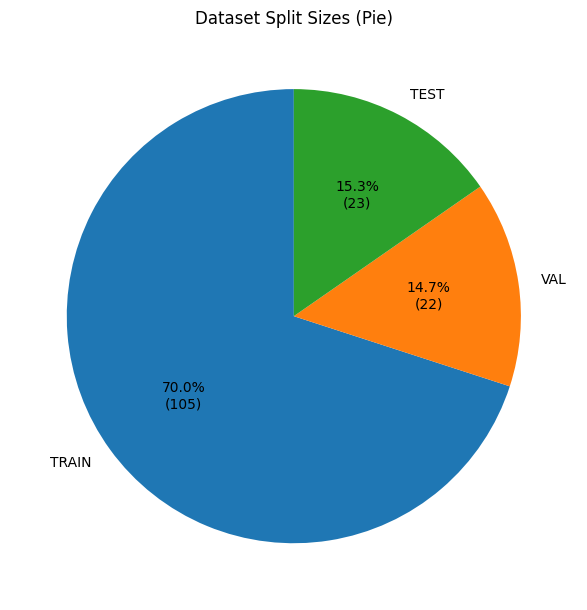

[Saved] meeting_summarizer_output_final/results/fig_split_sizes_bar.png


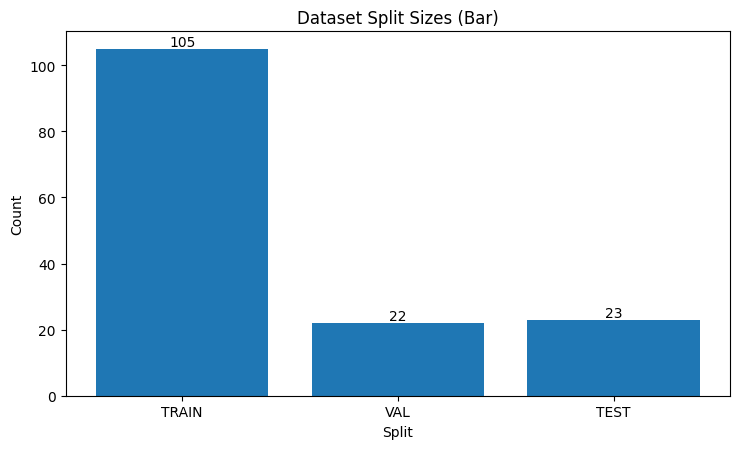

In [23]:
# Figure 8 — Pie/Bar of Split Sizes
# - Prints split counts & percentages
# - Compares to cfg split ratios (if defined)
# - Renders a pie chart and a bar chart
# - Saves PNGs to results dir (optional)

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SAVE_PNG  = True
PNG_PIE   = os.path.join(cfg.RESULTS_DIR, "fig_split_sizes_pie.png")
PNG_BAR   = os.path.join(cfg.RESULTS_DIR, "fig_split_sizes_bar.png")

def _safe_len(x):
    try:
        return len(x)
    except Exception:
        return 0

N_total = len(pool)

n_train = _safe_len(train_idx) if "train_idx" in globals() else 0
n_val   = _safe_len(val_idx)   if "val_idx"   in globals() else 0
n_test  = _safe_len(test_idx)  if "test_idx"  in globals() else 0

n_assigned    = n_train + n_val + n_test
n_unassigned  = max(0, N_total - n_assigned)

splits = ["TRAIN", "VAL", "TEST"] + (["UNASSIGNED"] if n_unassigned > 0 else [])
counts = [n_train, n_val, n_test] + ([n_unassigned] if n_unassigned > 0 else [])

df = pd.DataFrame({"Split": splits, "Count": counts})
df["Percent"] = (100.0 * df["Count"] / max(1, N_total)).round(2)

print("\nSplit Sizes")
display(df)

# Optional: show expected counts from cfg ratios
if hasattr(cfg, "TRAIN_RATIO") and hasattr(cfg, "VAL_RATIO") and hasattr(cfg, "TEST_RATIO"):
    ratios = np.array([cfg.TRAIN_RATIO, cfg.VAL_RATIO, cfg.TEST_RATIO], dtype=float)
    if ratios.sum() > 0:
        exp_counts = (ratios / ratios.sum() * N_total).round().astype(int)
        exp_map = {"TRAIN": int(exp_counts[0]), "VAL": int(exp_counts[1]), "TEST": int(exp_counts[2])}
        print("Expected counts (from cfg ratios):", exp_map)

# ---- Pie chart ----
plt.figure(figsize=(6.2, 6.2))
plt.pie(
    df["Count"].values,
    labels=df["Split"].values,
    autopct=lambda p: f"{p:.1f}%\n({int(round(p/100.0*N_total))})",
    startangle=90
)
plt.title("Dataset Split Sizes (Pie)")
plt.tight_layout()
if SAVE_PNG:
    os.makedirs(cfg.RESULTS_DIR, exist_ok=True)
    plt.savefig(PNG_PIE, dpi=150)
    print(f"[Saved] {PNG_PIE}")
plt.show()

# ---- Bar chart ----
plt.figure(figsize=(7.5, 4.6))
plt.bar(df["Split"].values, df["Count"].values)
for i, c in enumerate(df["Count"].values):
    plt.text(i, c, str(int(c)), ha="center", va="bottom")
plt.title("Dataset Split Sizes (Bar)")
plt.xlabel("Split")
plt.ylabel("Count")
plt.tight_layout()
if SAVE_PNG:
    plt.savefig(PNG_BAR, dpi=150)
    print(f"[Saved] {PNG_BAR}")
plt.show()


# Cell 8 — G-Eval (heuristic) metrics

In [ ]:
def _normalize(x, lo=0.0, hi=1.0):
    return max(lo, min(hi, x))

def _ratio(n, d):
    return 0.0 if d <= 0 else n / d

def _tokenize(s: str) -> List[str]:
    return re.findall(r"\w+", s.lower())

def geval_coherence(summary: str) -> float:
    sents = [s for s in sent_tokenize(summary) if s.strip()]
    if not sents:
        return 0.0
    avg_len = sum(len(_tokenize(s)) for s in sents) / len(sents)
    penalty_frag = 1.0 if avg_len >= 8 else avg_len / 8.0
    overlaps = []
    for i in range(len(sents) - 1):
        a = set(_tokenize(sents[i])); b = set(_tokenize(sents[i + 1]))
        overlaps.append(_ratio(len(a & b), len(a | b)))
    local = np.mean(overlaps) if overlaps else 0.0
    return _normalize(0.6 * penalty_frag + 0.4 * local)

def geval_consistency(summary: str, source: str) -> float:
    src = set(_tokenize(source))
    summ = _tokenize(summary)
    numbers = [t for t in summ if re.fullmatch(r"\d+", t)]
    proper_like = [p.lower() for p in re.findall(r"\b[A-Z][a-zA-Z]+\b", summary)]
    hallu = sum(1 for t in numbers + proper_like if t not in src)
    rate = 1.0 - _ratio(hallu, max(1, len(numbers) + len(proper_like)))
    return _normalize(rate)

def geval_fluency(summary: str) -> float:
    toks = _tokenize(summary)
    sents = [s for s in sent_tokenize(summary) if s.strip()]
    if not sents:
        return 0.0
    avg_len = len(toks) / len(sents)
    rep_pen = 1.0 - _ratio(len(toks) - len(set(toks)), max(1, len(toks)))
    len_score = 1.0 - min(1.0, abs(avg_len - 20) / 20)  # prefer ~20 toks/sent
    return _normalize(0.6 * len_score + 0.4 * rep_pen)

def geval_relevance(summary: str, source: str) -> float:
    src = set(_tokenize(source))
    summ = set(_tokenize(summary))
    j = _ratio(len(src & summ), len(summ))
    return _normalize(j)

ACTION_PAT = re.compile(r"^\s*\[(?P<owner>[^\]]+)\]\s*—\s*(?P<task>.+?)\s*—\s*Due:\s*(?P<due>[^\n]+)$", re.M)

def eval_action_quality(summary: str) -> float:
    matches = list(ACTION_PAT.finditer(summary))
    if not matches:
        return 0.2
    good = 0
    for m in matches:
        owner = (m.group("owner") or "").strip()
        task  = (m.group("task") or "").strip()
        if len(owner) >= 2 and len(task) >= 6:
            good += 1
    return _normalize(good / len(matches))

def geval_comprehensive(summary: str, source: str) -> Dict[str, float]:
    c1 = geval_coherence(summary)
    c2 = geval_consistency(summary, source)
    c3 = geval_fluency(summary)
    c4 = geval_relevance(summary, source)
    a1 = eval_action_quality(summary)
    overall = (c1 + c2 + c3 + c4 + a1) / 5.0
    prod = (
        cfg.WTS["coherence"]      * c1
      + cfg.WTS["consistency"]    * c2
      + cfg.WTS["fluency"]        * c3
      + cfg.WTS["relevance"]      * c4
      + cfg.WTS["action_quality"] * a1
    )
    return {
        "coherence":        10 * c1,
        "consistency":      10 * c2,
        "fluency":          10 * c3,
        "relevance":        10 * c4,
        "action_quality":   10 * a1,
        "geval_overall":    10 * overall,
        "production_score": 10 * prod,
    }


# Cell 9 — Model loader & long-text helper

In [ ]:
# Cell 9 — GPU-only loader + token-safe helpers

import os
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline

# Hard-require GPU for this workflow
if not torch.cuda.is_available():
    raise RuntimeError("CUDA not available; this run is GPU-only. Enable a GPU and re-run.")

# Disable SDPA for models that tend to trip device-side asserts (e.g., BART/PEGASUS)
os.environ["PYTORCH_CUDA_SDPA_DISABLED"] = "1"  # safest across PyTorch builds
torch.backends.cuda.matmul.allow_tf32 = True    # speed on 4090; harmless

def _is_t5(name: str) -> bool:
    return "t5" in name.lower()

def _is_bart_or_pegasus(name: str) -> bool:
    n = name.lower()
    return ("bart" in n) or ("pegasus" in n)

def _pick_dtype(model_name: str):
    # T5 works great in bf16 on 4090; prefer fp16 for BART/PEGASUS to avoid oddities
    if _is_bart_or_pegasus(model_name):
        return torch.float16
    return torch.bfloat16 if torch.cuda.get_device_capability(0)[0] >= 8 else torch.float16

def _set_attention_impl_if_supported(model, model_name: str):
    # Force 'eager' attention for BART/PEGASUS to avoid SDPA mask/device asserts
    try:
        if _is_bart_or_pegasus(model_name) and hasattr(model.config, "attn_implementation"):
            model.config.attn_implementation = "eager"
    except Exception:
        pass

def make_pipeline(model_name: str):
    """
    Force-load on CUDA:0 with a safe dtype and attention impl. No CPU fallback.
    """
    task = "text2text-generation" if _is_t5(model_name) else "summarization"
    tok = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    model = AutoModelForSeq2SeqLM.from_pretrained(model_name, torch_dtype=_pick_dtype(model_name))
    _set_attention_impl_if_supported(model, model_name)
    model.to("cuda:0")
    pipe = pipeline(task=task, model=model, tokenizer=tok, device=0)  # GPU:0 only

    p = next(model.parameters())
    print(f"[{model_name}] device → {p.device} | dtype={p.dtype} | attn_impl={getattr(model.config, 'attn_implementation', 'default')}")
    return pipe

def _safe_max_input_tokens(pipe) -> int:
    """
    Use the minimum of tokenizer + config limits (ignoring absurd sentinel values).
    """
    tok_lim = getattr(pipe.tokenizer, "model_max_length", None)
    cfg_lim = getattr(getattr(pipe.model, "config", None), "max_position_embeddings", None)
    candidates = [x for x in (tok_lim, cfg_lim) if isinstance(x, int) and 0 < x < 100000]
    if candidates:
        return min(candidates)
    # conservative defaults
    if _is_t5(getattr(pipe.model, "name_or_path", "")):
        return 512
    return 1024  # BART/PEGASUS typical

def _pipe_text(pipe, text: str) -> str:
    """
    Unified way to call the pipeline and get a string back.
    """
    out = pipe(text, **cfg.GEN)[0]
    if isinstance(out, dict):
        return out.get("generated_text", out.get("summary_text", ""))
    return out if isinstance(out, str) else ""

def summarize_with_token_chunks(pipe, prompt: str, margin: int = 64) -> str:
    """
    Split input by *tokens* so each chunk ≤ (max_in - margin) tokens.
    Prevents position-embedding overflows (source of device-side asserts).
    """
    tok = pipe.tokenizer
    max_in = _safe_max_input_tokens(pipe)
    chunk_len = max(128, max_in - margin)

    enc = tok(prompt, add_special_tokens=True, return_tensors="pt", truncation=False)
    ids = enc["input_ids"][0].tolist()

    if len(ids) <= chunk_len:
        return _pipe_text(pipe, prompt)

    partials = []
    for start in range(0, len(ids), chunk_len):
        piece_ids = ids[start:start + chunk_len]
        piece_text = tok.decode(piece_ids, skip_special_tokens=True)
        partials.append(_pipe_text(pipe, piece_text))

    combined = "\n".join(partials).strip()
    # Reduce phase is also token-safe (call ourselves recursively)
    reduce_prompt = build_instruction_prompt(combined)
    # If reduce still too long, we'll chunk again
    return summarize_with_token_chunks(pipe, reduce_prompt, margin=margin)


# Cell 10 — Generation API (shared)

In [ ]:
# Cell 10 — Generation API (token-chunking for all models)
def generate_summary_with_prompt(pipe, transcript: str, use_meeting_prompt: bool = True) -> str:
    prompt = build_meeting_prompt(transcript, FEW_SHOT_EXAMPLES) if use_meeting_prompt else build_instruction_prompt(transcript)
    return summarize_with_token_chunks(pipe, prompt, margin=64)


# Cell 11 — Evaluate all models on VAL; pick Top-2 by Production Score

In [ ]:
# Cell 11 — Hybrid VAL evaluation:
#  - FAST models (e.g., T5) → batched & truncated (quick)
#  - SLOW models (BART/PEGASUS) → sequential & token-chunked (safe)
#  - Incremental/resume-safe artifacts + final ranking / top-2

import os, json, time, glob, gc
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import torch

# ---------------------------------------------------------------------
# Use overrides if set earlier; else read from cfg.*
# ---------------------------------------------------------------------
EVAL_ONLY       = globals().get("EVAL_ONLY",      cfg.EVAL_ONLY)
VAL_SAMPLE_CAP  = globals().get("VAL_SAMPLE_CAP", cfg.VAL_SAMPLE_CAP)
SKIP_IF_EXISTS  = globals().get("SKIP_IF_EXISTS", cfg.SKIP_IF_EXISTS)

# Choose which models are fast vs slow (can override by defining FAST_MODELS/SLOW_MODELS before this cell)
FAST_MODELS = set(globals().get("FAST_MODELS", ["FLAN-T5-BASE", "FLAN-T5-LARGE"]))
SLOW_MODELS = set(globals().get("SLOW_MODELS", ["BART-CNN", "PEGASUS-XSUM"]))

# Batch size for fast models (tune for your GPU)
FAST_BATCH_SIZE = globals().get("FAST_BATCH_SIZE", 4)

def _gpu_report(prefix=""):
    if torch.cuda.is_available():
        try:
            name = torch.cuda.get_device_name(0)
            props = torch.cuda.get_device_properties(0)
            used = torch.cuda.memory_allocated(0) / (1024**3)
            reserved = torch.cuda.memory_reserved(0) / (1024**3)
            total = props.total_memory / (1024**3)
            print(f"{prefix}GPU: {name} | VRAM: {used:.2f}GB used / {reserved:.2f}GB reserved / {total:.1f}GB total")
        except Exception as e:
            print(f"{prefix}GPU: available (introspection failed: {e})")
    else:
        print(f"{prefix}CPU only")

def _aggressive_cleanup():
    gc.collect()
    if torch.cuda.is_available():
        try:
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()
            torch.cuda.synchronize()
        except Exception:
            pass

def _truncate_to_tokens(pipe, text: str, max_tokens: int) -> str:
    tok = pipe.tokenizer
    ids = tok.encode(text, add_special_tokens=True)
    if len(ids) <= max_tokens:
        return text
    ids = ids[:max_tokens]
    return tok.decode(ids, skip_special_tokens=True)

# --- announce run ---
print("\n======================================================================")
print("MODEL EVALUATION (HYBRID: FAST batched + SLOW sequential)")
print("======================================================================\n")
print("[OK] All required variables loaded\n")

if 'val_idx' not in globals():
    raise RuntimeError("val_idx not found — run Cell 6 to create dataset splits.")

print(f"Validation samples: {len(val_idx)}\n")
print("[System] Initial GPU state:")
_gpu_report(prefix="[System] ")

# choose which models to run now
all_items = list(cfg.MODELS.items())
if EVAL_ONLY:
    missing = [m for m in EVAL_ONLY if m not in cfg.MODELS]
    if missing:
        raise ValueError(f"Unknown models in EVAL_ONLY: {missing}.\nAvailable: {list(cfg.MODELS.keys())}")
    items = [(m, cfg.MODELS[m]) for m in EVAL_ONLY]
else:
    items = all_items

# order: fast models first (quick), then slow (safe sequential)
fast_items = [(m, n) for (m, n) in items if m in FAST_MODELS]
slow_items = [(m, n) for (m, n) in items if m in SLOW_MODELS]
other_items = [(m, n) for (m, n) in items if (m not in FAST_MODELS and m not in SLOW_MODELS)]

# Evaluate fast → other → slow (you can reorder if you prefer)
ordered_items = fast_items + other_items + slow_items

print("\nPlanned order:")
for k, v in ordered_items:
    tag = "FAST" if k in FAST_MODELS else ("SLOW" if k in SLOW_MODELS else "OTHER")
    print(f"  - {k} ({tag}): {v}")

# build VAL rows
val_rows = [pool[i] for i in val_idx]
if VAL_SAMPLE_CAP:
    val_rows = val_rows[:VAL_SAMPLE_CAP]

# paths
per_sample_dir = cfg.RESULTS_DIR
agg_dir = cfg.RESULTS_DIR
os.makedirs(per_sample_dir, exist_ok=True)

# session trackers
session_val_records = []
session_model_avgs = []

print("\n======================================================================")
for i, (label, mname) in enumerate(ordered_items, start=1):
    print(f"=== Evaluating {label} ({i}/{len(ordered_items)}) ===")
    print("======================================================================")
    per_sample_csv = os.path.join(per_sample_dir, f"val_metrics__{label}.csv")
    agg_json       = os.path.join(agg_dir,       f"val_agg__{label}.json")

    if SKIP_IF_EXISTS and os.path.exists(per_sample_csv) and os.path.exists(agg_json):
        print(f"[{label}] Found existing artifacts; skipping (SKIP_IF_EXISTS=True).")
        continue

    # Clean memory and report
    print(f"[{label}] Cleaning GPU memory before load...")
    _aggressive_cleanup()
    print(f"[{label}] Before load:", end=" ")
    _gpu_report(prefix="")

    # Load model/pipeline on GPU (uses your Cell 9 GPU-only loader)
    pipe = make_pipeline(mname)

    # Device/dtype info
    try:
        p = next(pipe.model.parameters())
        dev = getattr(p.device, "type", "unknown").upper()
        idx = getattr(p.device, "index", None)
        dtype = str(p.dtype).replace("torch.", "")
        loc = f"{dev}:{idx}" if (dev == "CUDA" and idx is not None) else dev
        print(f"[{label}] Model loaded: {loc} | dtype={dtype}")
        print(f"[{label}] After load:", end=" ")
        _gpu_report(prefix="")
    except Exception as e:
        print(f"[{label}] Could not introspect device/dtype: {e}")

    # Evaluate
    t0 = time.time()
    model_records = []
    succeeded = 0
    failed = 0

    # --- FAST path: batched & truncated single-chunk (quick) ---
    if label in FAST_MODELS:
        # Compute a safe one-chunk length
        max_in = _safe_max_input_tokens(pipe)  # from Cell 9
        chunk_len = max(128, max_in - 64)

        # Build truncated prompts once
        prompts = []
        sample_ids = []
        for ridx, row in enumerate(val_rows):
            transcript = get_transcript(row)
            if not transcript or not transcript.strip():
                continue
            prompt = build_meeting_prompt(transcript, FEW_SHOT_EXAMPLES) if cfg.USE_MEETING_PROMPT else build_instruction_prompt(transcript)
            prompt = _truncate_to_tokens(pipe, prompt, chunk_len)
            prompts.append(prompt)
            sample_ids.append(val_idx[ridx])

        # Batched inference
        sample_times = []
        for b in tqdm(range(0, len(prompts), FAST_BATCH_SIZE), desc=f"  {label} (fast/batched)", leave=False):
            batch = prompts[b:b+FAST_BATCH_SIZE]
            t_s = time.time()
            try:
                with torch.inference_mode():
                    outs = pipe(batch, batch_size=FAST_BATCH_SIZE, **cfg.GEN)
            except Exception as e:
                print(f"\n[{label}] batch {b//FAST_BATCH_SIZE} - Error: {str(e)[:120]}")
                failed += len(batch)
                _aggressive_cleanup()
                continue
            dt = time.time() - t_s
            per_sample = dt / max(1, len(batch))
            sample_times.extend([per_sample] * len(batch))

            # Normalize outputs to strings
            texts = []
            for o in outs:
                if isinstance(o, dict):
                    texts.append(o.get("generated_text", o.get("summary_text", "")))
                elif isinstance(o, list) and o and isinstance(o[0], dict):
                    texts.append(o[0].get("generated_text", o[0].get("summary_text", "")))
                else:
                    texts.append(str(o))

            # Score & record
            for k, summ in enumerate(texts):
                idx_global = sample_ids[b + k]
                transcript = get_transcript(pool[idx_global])
                metrics = geval_comprehensive(summ, transcript)
                rec = {"model": label, "sample_index": idx_global, **metrics}
                model_records.append(rec)
                succeeded += 1

        wall = time.time() - t0
        sec_mean = float(np.mean(sample_times)) if sample_times else float("nan")
        sec_p50  = float(np.median(sample_times)) if sample_times else float("nan")
        sec_p90  = float(np.percentile(sample_times, 90)) if sample_times else float("nan")

    # --- SLOW path: sequential & token-chunked (safe) ---
    else:
        sample_times = []
        for ridx, row in enumerate(tqdm(val_rows, desc=f"  {label} (slow/sequential)", leave=False)):
            transcript = get_transcript(row)
            if not transcript or not transcript.strip():
                failed += 1
                continue
            t_s = time.time()
            try:
                with torch.inference_mode():
                    # summarize_with_token_chunks from Cell 9 via generate_summary_with_prompt
                    summ = generate_summary_with_prompt(pipe, transcript, use_meeting_prompt=cfg.USE_MEETING_PROMPT)
            except Exception as e:
                print(f"\n[{label}] sample {ridx} - Error: {str(e)[:120]}")
                failed += 1
                _aggressive_cleanup()
                continue

            sample_times.append(time.time() - t_s)
            metrics = geval_comprehensive(summ, transcript)
            rec = {"model": label, "sample_index": val_idx[ridx], **metrics}
            model_records.append(rec)
            succeeded += 1

        wall = time.time() - t0
        sec_mean = float(np.mean(sample_times)) if sample_times else float("nan")
        sec_p50  = float(np.median(sample_times)) if sample_times else float("nan")
        sec_p90  = float(np.percentile(sample_times, 90)) if sample_times else float("nan")

    # Save per-sample records for this model
    if model_records:
        dfm = pd.DataFrame(model_records)
        dfm.to_csv(per_sample_csv, index=False)

        avg = dfm[[
            "coherence","consistency","fluency","relevance",
            "action_quality","production_score","geval_overall"
        ]].mean().to_dict()

        avg.update({
            "model": label,
            "wall_time_sec": wall,
            "sec_per_sample_mean": sec_mean,
            "sec_per_sample_p50":  sec_p50,
            "sec_per_sample_p90":  sec_p90,
            "succeeded": succeeded,
            "failed": failed,
            "num_samples": len(val_rows),
            "mode": "FAST" if label in FAST_MODELS else ("SLOW" if label in SLOW_MODELS else "OTHER"),
            "batch_size": FAST_BATCH_SIZE if label in FAST_MODELS else 1,
        })

        with open(agg_json, "w") as f:
            json.dump(avg, f, indent=2)

        session_val_records.extend(model_records)
        session_model_avgs.append(avg)

        print(f"\n[{label}] Completed: {succeeded}/{succeeded+failed} succeeded, {failed} failed")
        print(f"[{label}] Speed:", {k: round(v,2) for k,v in avg.items()
                                    if k in {'wall_time_sec','sec_per_sample_mean','sec_per_sample_p50','sec_per_sample_p90','batch_size'}})
        print(f"[{label}] Metrics (VAL):", {k: round(v,2) for k,v in avg.items()
                                  if k in {'coherence','consistency','fluency','relevance','action_quality','production_score','geval_overall'}})
        print(f"[{label}] Saved per-sample → {per_sample_csv}")
        print(f"[{label}] Saved aggregate  → {agg_json}")
    else:
        print(f"\n[{label}] No successful samples; not writing artifacts.")

    # Cleanup this model before next
    print(f"\n[{label}] Cleaning up model and freeing memory...")
    try:
        del pipe
    except Exception:
        pass
    _aggressive_cleanup()
    print(f"[{label}] After cleanup:", end=" ")
    _gpu_report(prefix="")
    print("\n")

# -----------------------------
# Rebuild global ranking by loading *all* per-model aggregates on disk
# -----------------------------
agg_files = sorted(glob.glob(os.path.join(agg_dir, "val_agg__*.json")))
all_aggs = []
for ap in agg_files:
    try:
        with open(ap, "r") as f:
            all_aggs.append(json.load(f))
    except Exception as e:
        print("[Rank] Could not load", ap, ":", e)

if not all_aggs and session_model_avgs:
    all_aggs = session_model_avgs

if not all_aggs:
    raise RuntimeError("No aggregates found to rank. Did any model finish successfully?")

rank_df = pd.DataFrame(all_aggs).sort_values("production_score", ascending=False)
val_rank_csv = os.path.join(cfg.RESULTS_DIR, "llm_geval_val_model_ranking.csv")
rank_df.to_csv(val_rank_csv, index=False)

print("VAL ranking (by Production Score):")
print(rank_df[[
    "model","mode","production_score","geval_overall","coherence",
    "consistency","relevance","action_quality","fluency",
    "sec_per_sample_mean","wall_time_sec","batch_size"
]])

TOP2 = rank_df.head(2)["model"].tolist()
with open(os.path.join(cfg.RESULTS_DIR, "selected_top2.json"), "w") as f:
    json.dump({"top2_models": TOP2}, f, indent=2)
print("\nSelected top-2:", TOP2)



MODEL EVALUATION (HYBRID: FAST batched + SLOW sequential)

[OK] All required variables loaded

Validation samples: 22

[System] Initial GPU state:
[System] GPU: NVIDIA GeForce RTX 4090 | VRAM: 0.00GB used / 0.00GB reserved / 24.0GB total

Planned order:
  - FLAN-T5-BASE (FAST): google/flan-t5-base
  - FLAN-T5-LARGE (FAST): google/flan-t5-large
  - BART-CNN (SLOW): facebook/bart-large-cnn
  - PEGASUS-XSUM (SLOW): google/pegasus-xsum

=== Evaluating FLAN-T5-BASE (1/4) ===
[FLAN-T5-BASE] Cleaning GPU memory before load...
[FLAN-T5-BASE] Before load: GPU: NVIDIA GeForce RTX 4090 | VRAM: 0.00GB used / 0.00GB reserved / 24.0GB total


Token indices sequence length is longer than the specified maximum sequence length for this model (11613 > 512). Running this sequence through the model will result in indexing errors


[google/flan-t5-base] device → cuda:0 | dtype=torch.bfloat16 | attn_impl=default
[FLAN-T5-BASE] Model loaded: CUDA:0 | dtype=bfloat16
[FLAN-T5-BASE] After load: GPU: NVIDIA GeForce RTX 4090 | VRAM: 0.47GB used / 0.49GB reserved / 24.0GB total



[FLAN-T5-BASE] Completed: 22/22 succeeded, 0 failed
[FLAN-T5-BASE] Speed: {'wall_time_sec': 14.7, 'sec_per_sample_mean': 0.66, 'sec_per_sample_p50': 0.6, 'sec_per_sample_p90': 0.79, 'batch_size': 4}
[FLAN-T5-BASE] Metrics (VAL): {'coherence': 6.05, 'consistency': 5.92, 'fluency': 5.97, 'relevance': 6.91, 'action_quality': 2.0, 'production_score': 5.42, 'geval_overall': 5.37}
[FLAN-T5-BASE] Saved per-sample → meeting_summarizer_output_final/results/val_metrics__FLAN-T5-BASE.csv
[FLAN-T5-BASE] Saved aggregate  → meeting_summarizer_output_final/results/val_agg__FLAN-T5-BASE.json

[FLAN-T5-BASE] Cleaning up model and freeing memory...
[FLAN-T5-BASE] After cleanup: GPU: NVIDIA GeForce RTX 4090 | VRAM: 0.05GB used / 0.07GB reserved / 24.0GB total


=== Evaluating FLAN-T5-LARGE (2/4) ===
[FLAN-T5-LARGE] Cleaning GPU memory before load...
[FLAN-T5-LARGE] Before load: GPU: NVIDIA GeForce RTX 4090 | VRAM: 0.05GB used / 0.07GB reserved / 24.0GB total


Token indices sequence length is longer than the specified maximum sequence length for this model (11613 > 512). Running this sequence through the model will result in indexing errors


...


[BART-CNN] Completed: 22/22 succeeded, 0 failed
[BART-CNN] Speed: {'wall_time_sec': 205.3, 'sec_per_sample_mean': 9.33, 'sec_per_sample_p50': 9.43, 'sec_per_sample_p90': 13.26, 'batch_size': 1}
[BART-CNN] Metrics (VAL): {'coherence': 6.23, 'consistency': 4.22, 'fluency': 7.98, 'relevance': 5.0, 'action_quality': 2.0, 'production_score': 4.75, 'geval_overall': 5.08}
[BART-CNN] Saved per-sample → meeting_summarizer_output_final/results/val_metrics__BART-CNN.csv
[BART-CNN] Saved aggregate  → meeting_summarizer_output_final/results/val_agg__BART-CNN.json

[BART-CNN] Cleaning up model and freeing memory...
[BART-CNN] After cleanup: GPU: NVIDIA GeForce RTX 4090 | VRAM: 0.10GB used / 0.12GB reserved / 24.0GB total


=== Evaluating PEGASUS-XSUM (4/4) ===
[PEGASUS-XSUM] Cleaning GPU memory before load...
[PEGASUS-XSUM] Before load: GPU: NVIDIA GeForce RTX 4090 | VRAM: 0.10GB used / 0.12GB reserved / 24.0GB total


Some weights of PegasusForConditionalGeneration were not initialized from the model checkpoint at google/pegasus-xsum and are newly initialized: ['model.decoder.embed_positions.weight', 'model.encoder.embed_positions.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[google/pegasus-xsum] device → cuda:0 | dtype=torch.float16 | attn_impl=default
[PEGASUS-XSUM] Model loaded: CUDA:0 | dtype=float16
[PEGASUS-XSUM] After load: GPU: NVIDIA GeForce RTX 4090 | VRAM: 1.07GB used / 1.18GB reserved / 24.0GB total


  PEGASUS-XSUM (slow/sequential):   0%|          | 0/22 [00:00<?, ?it/s]Token indices sequence length is longer than the specified maximum sequence length for this model (10477 > 512). Running this sequence through the model will result in indexing errors
Your max_length is set to 256, but your input_length is only 159. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=79)
Your max_length is set to 256, but your input_length is only 66. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=33)
Your max_length is set to 256, but your input_length is only 61. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=


[PEGASUS-XSUM] Completed: 22/22 succeeded, 0 failed
[PEGASUS-XSUM] Speed: {'wall_time_sec': 1020.45, 'sec_per_sample_mean': 46.38, 'sec_per_sample_p50': 45.52, 'sec_per_sample_p90': 65.19, 'batch_size': 1}
[PEGASUS-XSUM] Metrics (VAL): {'coherence': 6.36, 'consistency': 4.42, 'fluency': 2.85, 'relevance': 6.4, 'action_quality': 2.0, 'production_score': 4.66, 'geval_overall': 4.41}
[PEGASUS-XSUM] Saved per-sample → meeting_summarizer_output_final/results/val_metrics__PEGASUS-XSUM.csv
[PEGASUS-XSUM] Saved aggregate  → meeting_summarizer_output_final/results/val_agg__PEGASUS-XSUM.json

[PEGASUS-XSUM] Cleaning up model and freeing memory...
[PEGASUS-XSUM] After cleanup: GPU: NVIDIA GeForce RTX 4090 | VRAM: 0.19GB used / 0.20GB reserved / 24.0GB total


VAL ranking (by Production Score):
           model  mode  production_score  geval_overall  coherence  \
2  FLAN-T5-LARGE  FAST          6.310876       5.996968   5.537437   
1   FLAN-T5-BASE  FAST          5.415607       5.370522   6.04900

# Cell 12 — Run TEST for Top-2 and save outputs + metrics

In [ ]:
# Cell 12 — TEST evaluation for TOP-2 (hybrid fast/slow, incremental/resume-safe)

import os, json, time, gc
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import torch

# ------------------------ knobs (override here if desired) ------------------------
EVAL_ONLY_TEST        = globals().get("EVAL_ONLY_TEST", None)   # e.g., ["FLAN-T5-LARGE"] to run only one of the top-2
TEST_SAMPLE_CAP       = globals().get("TEST_SAMPLE_CAP", None)  # e.g., 30 for a quick pass; None = full TEST split
SKIP_IF_EXISTS_TEST   = globals().get("SKIP_IF_EXISTS_TEST", False)

# Model speed classes (can override before this cell)
FAST_MODELS           = set(globals().get("FAST_MODELS", ["FLAN-T5-BASE", "FLAN-T5-LARGE"]))
SLOW_MODELS           = set(globals().get("SLOW_MODELS", ["BART-CNN", "PEGASUS-XSUM"]))

FAST_BATCH_SIZE_TEST  = globals().get("FAST_BATCH_SIZE_TEST", 4)  # bump to 6–8 on a 4090 if VRAM allows
FLUSH_EVERY           = globals().get("FLUSH_EVERY", 5)           # write partial CSV every N samples (robust to interrupts)
# ----------------------------------------------------------------------------------

def _gpu_report(prefix=""):
    if torch.cuda.is_available():
        try:
            name = torch.cuda.get_device_name(0)
            props = torch.cuda.get_device_properties(0)
            used = torch.cuda.memory_allocated(0) / (1024**3)
            reserved = torch.cuda.memory_reserved(0) / (1024**3)
            total = props.total_memory / (1024**3)
            print(f"{prefix}GPU: {name} | VRAM: {used:.2f}GB used / {reserved:.2f}GB reserved / {total:.1f}GB total")
        except Exception as e:
            print(f"{prefix}GPU: available (introspection failed: {e})")
    else:
        print(f"{prefix}CPU only")

def _aggressive_cleanup():
    gc.collect()
    if torch.cuda.is_available():
        try:
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()
            torch.cuda.synchronize()
        except Exception:
            pass

def _truncate_to_tokens(pipe, text: str, max_tokens: int) -> str:
    tok = pipe.tokenizer
    ids = tok.encode(text, add_special_tokens=True)
    if len(ids) <= max_tokens:
        return text
    return tok.decode(ids[:max_tokens], skip_special_tokens=True)

# ------------------------ determine TOP-2 ------------------------
TOP2 = globals().get("TOP2", None)
if not TOP2:
    try:
        with open(os.path.join(cfg.RESULTS_DIR, "selected_top2.json"), "r") as f:
            TOP2 = json.load(f)["top2_models"]
    except Exception as e:
        raise RuntimeError("TOP2 not found; run Cell 11 first.") from e

# optional override (e.g., run only one of the top-2 right now)
if EVAL_ONLY_TEST:
    chosen = [m for m in TOP2 if m in EVAL_ONLY_TEST]
    if not chosen:
        # allow running a specific model even if it wasn't in TOP2
        chosen = EVAL_ONLY_TEST
else:
    chosen = TOP2

# order: fast first, then slow (so you get quick results early)
ordered = [m for m in chosen if m in FAST_MODELS] + \
          [m for m in chosen if m in SLOW_MODELS] + \
          [m for m in chosen if (m not in FAST_MODELS and m not in SLOW_MODELS)]

print("\n======================================================================")
print("TOP-2 TEST EVALUATION (HYBRID: FAST batched + SLOW sequential)")
print("======================================================================\n")
print(f"Selected models: {ordered}")
print(f"TEST set size: {len(test_idx)}")
if TEST_SAMPLE_CAP:
    print(f"TEST cap in effect: {TEST_SAMPLE_CAP}")

test_rows = [pool[i] for i in test_idx]
if TEST_SAMPLE_CAP:
    test_rows = test_rows[:TEST_SAMPLE_CAP]

print("\n[System] Initial GPU state:")
_gpu_report(prefix="[System] ")

all_test_records = []
per_model_summary_paths = {}

for label in ordered:
    mname = cfg.MODELS.get(label)
    if not mname:
        print(f"[WARN] Model label {label} not in cfg.MODELS — skipping.")
        continue

    out_dir = os.path.join(cfg.GEN_DIR, f"test__{label}")
    os.makedirs(out_dir, exist_ok=True)
    csv_path = os.path.join(cfg.RESULTS_DIR, f"test_metrics__{label}.csv")
    part_csv = csv_path + ".part"

    if SKIP_IF_EXISTS_TEST and os.path.exists(csv_path):
        print(f"\n>>> Skipping {label} — found existing TEST metrics at {csv_path}")
        per_model_summary_paths[label] = out_dir
        continue

    print(f"\n>>> Running TEST with {label} ({mname})")
    print(f"[{label}] Cleaning GPU memory before load...")
    _aggressive_cleanup()
    print(f"[{label}] Before load:", end=" ")
    _gpu_report(prefix="")

    # Build pipeline (GPU-only as per Cell 9)
    pipe = make_pipeline(mname)

    # Device/dtype info
    try:
        p = next(pipe.model.parameters())
        dev = getattr(p.device, "type", "unknown").upper()
        idx = getattr(p.device, "index", None)
        dtype = str(p.dtype).replace("torch.", "")
        loc = f"{dev}:{idx}" if (dev == "CUDA" and idx is not None) else dev
        print(f"[{label}] Model loaded: {loc} | dtype={dtype}")
        print(f"[{label}] After load:", end=" ")
        _gpu_report(prefix="")
    except Exception as e:
        print(f"[{label}] Could not introspect device/dtype: {e}")

    t0 = time.time()
    model_recs = []
    succeeded = 0
    failed = 0

    # --------------- FAST PATH: batched & truncated one-chunk ---------------
    if label in FAST_MODELS:
        max_in = _safe_max_input_tokens(pipe)   # from Cell 9
        chunk_len = max(128, max_in - 64)

        # Prepare prompts once
        prompts = []
        meta = []   # (global_idx, meeting_id, date)
        for ridx, row in enumerate(test_rows):
            transcript = get_transcript(row)
            if not transcript or not transcript.strip():
                continue
            prompt = build_meeting_prompt(transcript, FEW_SHOT_EXAMPLES) if cfg.USE_MEETING_PROMPT else build_instruction_prompt(transcript)
            prompt = _truncate_to_tokens(pipe, prompt, chunk_len)
            gidx = test_idx[ridx]
            mid  = get_val(row, ID_KEYS,  f"test_{gidx}")
            date = get_val(row, DATE_KEYS, None)
            prompts.append(prompt)
            meta.append((gidx, mid, date))

        # Batched inference
        for b in tqdm(range(0, len(prompts), FAST_BATCH_SIZE_TEST), desc=f"  TEST {label} (fast/batched)", leave=False):
            batch_prompts = prompts[b:b+FAST_BATCH_SIZE_TEST]
            batch_meta    = meta[b:b+FAST_BATCH_SIZE_TEST]
            try:
                t_s = time.time()
                with torch.inference_mode():
                    outs = pipe(batch_prompts, batch_size=FAST_BATCH_SIZE_TEST, **cfg.GEN)
                dt = time.time() - t_s
            except Exception as e:
                print(f"[{label}] batch {b//FAST_BATCH_SIZE_TEST} failed: {str(e)[:120]}")
                failed += len(batch_prompts)
                _aggressive_cleanup()
                continue

            # Normalize outputs
            texts = []
            for o in outs:
                if isinstance(o, dict):
                    texts.append(o.get("generated_text", o.get("summary_text", "")))
                elif isinstance(o, list) and o and isinstance(o[0], dict):
                    texts.append(o[0].get("generated_text", o[0].get("summary_text", "")))
                else:
                    texts.append(str(o))

            # Score + write summaries
            for (gidx, mid, date), summ in zip(batch_meta, texts):
                transcript = get_transcript(pool[gidx])
                # Save summary markdown
                with open(os.path.join(out_dir, f"{mid}.md"), "w") as f:
                    f.write(summ)
                metrics = geval_comprehensive(summ, transcript)
                rec = {"model": label, "meeting_id": mid, "date": date, **metrics}
                model_recs.append(rec)
                all_test_records.append(rec)
                succeeded += 1

            # periodic flush to .part CSV
            if FLUSH_EVERY and (len(model_recs) % FLUSH_EVERY == 0):
                pd.DataFrame(model_recs).to_csv(part_csv, index=False)

    # --------------- SLOW PATH: sequential & token-chunked ------------------
    else:
        for ridx, row in enumerate(tqdm(test_rows, desc=f"  TEST {label} (slow/sequential)", leave=False)):
            transcript = get_transcript(row)
            if not transcript or not transcript.strip():
                failed += 1
                continue
            try:
                with torch.inference_mode():
                    summ = generate_summary_with_prompt(
                        pipe, transcript, use_meeting_prompt=cfg.USE_MEETING_PROMPT
                    )
            except Exception as e:
                print(f"[TEST {label}] sample {ridx} failed: {str(e)[:120]}")
                failed += 1
                _aggressive_cleanup()
                continue

            gidx = test_idx[ridx]
            mid  = get_val(row, ID_KEYS,  f"test_{gidx}")
            date = get_val(row, DATE_KEYS, None)

            with open(os.path.join(out_dir, f"{mid}.md"), "w") as f:
                f.write(summ)

            metrics = geval_comprehensive(summ, transcript)
            rec = {"model": label, "meeting_id": mid, "date": date, **metrics}
            model_recs.append(rec)
            all_test_records.append(rec)
            succeeded += 1

            # periodic flush to .part CSV
            if FLUSH_EVERY and (len(model_recs) % FLUSH_EVERY == 0):
                pd.DataFrame(model_recs).to_csv(part_csv, index=False)

    wall = time.time() - t0

    # write final CSV for this model
    if model_recs:
        dfm = pd.DataFrame(model_recs)
        dfm.to_csv(csv_path, index=False)
        if os.path.exists(part_csv):
            try:
                os.remove(part_csv)
            except Exception:
                pass

        avg = dfm[[
            "coherence","consistency","fluency","relevance",
            "action_quality","production_score","geval_overall"
        ]].mean().to_dict()
        mode = "FAST" if label in FAST_MODELS else ("SLOW" if label in SLOW_MODELS else "OTHER")
        avg.update({
            "model": label,
            "mode": mode,
            "wall_time_sec": wall,
            "sec_per_sample_mean": float(wall / max(1, len(model_recs))),
            "batch_size": FAST_BATCH_SIZE_TEST if mode == "FAST" else 1,
            "succeeded": succeeded,
            "failed": failed,
            "num_samples": len(test_rows),
        })

        print(f"\n[{label}] TEST done: {succeeded}/{succeeded+failed} succeeded, {failed} failed")
        print(f"[{label}] Speed:", {k: round(v,2) for k,v in avg.items()
                                    if k in {'wall_time_sec','sec_per_sample_mean','batch_size'}})
        print(f"[{label}] Metrics (TEST):", {k: round(v,2) for k,v in avg.items()
                                    if k in {'coherence','consistency','fluency','relevance','action_quality','production_score','geval_overall'}})
        print(f"[{label}] Saved summaries → {out_dir}")
        print(f"[{label}] Saved TEST metrics → {csv_path}")

        per_model_summary_paths[label] = out_dir
    else:
        print(f"\n[{label}] No successful TEST samples; nothing written.")

    # cleanup before next model
    try:
        del pipe
    except Exception:
        pass
    _aggressive_cleanup()
    print(f"[{label}] After cleanup:", end=" ")
    _gpu_report(prefix="")
    print()

# --------------- Combine all TEST results from this run ---------------
all_test_df = pd.DataFrame(all_test_records)
all_test_csv = os.path.join(cfg.RESULTS_DIR, "top2_test_geval_scores.csv")
if len(all_test_df):
    all_test_df.to_csv(all_test_csv, index=False)
    print(f"\nSaved combined TEST metrics → {all_test_csv}")
else:
    print("\n[WARN] No TEST records produced in this run.")



TOP-2 TEST EVALUATION (HYBRID: FAST batched + SLOW sequential)

Selected models: ['FLAN-T5-LARGE', 'FLAN-T5-BASE']
TEST set size: 23

[System] Initial GPU state:
[System] GPU: NVIDIA GeForce RTX 4090 | VRAM: 2.08GB used / 2.45GB reserved / 24.0GB total

>>> Running TEST with FLAN-T5-LARGE (google/flan-t5-large)
[FLAN-T5-LARGE] Cleaning GPU memory before load...
[FLAN-T5-LARGE] Before load: GPU: NVIDIA GeForce RTX 4090 | VRAM: 1.69GB used / 1.74GB reserved / 24.0GB total


Token indices sequence length is longer than the specified maximum sequence length for this model (9770 > 512). Running this sequence through the model will result in indexing errors


[google/flan-t5-large] device → cuda:0 | dtype=torch.bfloat16 | attn_impl=default
[FLAN-T5-LARGE] Model loaded: CUDA:0 | dtype=bfloat16
[FLAN-T5-LARGE] After load: GPU: NVIDIA GeForce RTX 4090 | VRAM: 1.51GB used / 3.27GB reserved / 24.0GB total



[FLAN-T5-LARGE] TEST done: 23/23 succeeded, 0 failed
[FLAN-T5-LARGE] Speed: {'wall_time_sec': 24.98, 'sec_per_sample_mean': 1.09, 'batch_size': 4}
[FLAN-T5-LARGE] Metrics (TEST): {'coherence': 5.63, 'consistency': 8.21, 'fluency': 5.68, 'relevance': 8.77, 'action_quality': 2.0, 'production_score': 6.34, 'geval_overall': 6.06}
[FLAN-T5-LARGE] Saved summaries → meeting_summarizer_output_final/meetings/test__FLAN-T5-LARGE
[FLAN-T5-LARGE] Saved TEST metrics → meeting_summarizer_output_final/results/test_metrics__FLAN-T5-LARGE.csv
[FLAN-T5-LARGE] After cleanup: GPU: NVIDIA GeForce RTX 4090 | VRAM: 0.07GB used / 0.08GB reserved / 24.0GB total


>>> Running TEST with FLAN-T5-BASE (google/flan-t5-base)
[FLAN-T5-BASE] Cleaning GPU memory before load...
[FLAN-T5-BASE] Before load: GPU: NVIDIA GeForce RTX 4090 | VRAM: 0.07GB used / 0.08GB reserved / 24.0GB total


Token indices sequence length is longer than the specified maximum sequence length for this model (9770 > 512). Running this sequence through the model will result in indexing errors


[google/flan-t5-base] device → cuda:0 | dtype=torch.bfloat16 | attn_impl=default
[FLAN-T5-BASE] Model loaded: CUDA:0 | dtype=bfloat16
[FLAN-T5-BASE] After load: GPU: NVIDIA GeForce RTX 4090 | VRAM: 0.48GB used / 0.55GB reserved / 24.0GB total



[FLAN-T5-BASE] TEST done: 23/23 succeeded, 0 failed
[FLAN-T5-BASE] Speed: {'wall_time_sec': 23.58, 'sec_per_sample_mean': 1.03, 'batch_size': 4}
[FLAN-T5-BASE] Metrics (TEST): {'coherence': 5.83, 'consistency': 6.06, 'fluency': 6.49, 'relevance': 7.22, 'action_quality': 2.0, 'production_score': 5.54, 'geval_overall': 5.52}
[FLAN-T5-BASE] Saved summaries → meeting_summarizer_output_final/meetings/test__FLAN-T5-BASE
[FLAN-T5-BASE] Saved TEST metrics → meeting_summarizer_output_final/results/test_metrics__FLAN-T5-BASE.csv
[FLAN-T5-BASE] After cleanup: GPU: NVIDIA GeForce RTX 4090 | VRAM: 0.05GB used / 0.07GB reserved / 24.0GB total


Saved combined TEST metrics → meeting_summarizer_output_final/results/top2_test_geval_scores.csv


In [ ]:
# Cell 13 — Select BEST model from saved VAL ranking / artifacts

import os, json
import pandas as pd

rank_csv  = os.path.join(cfg.RESULTS_DIR, "llm_geval_val_model_ranking.csv")
sel_top2  = os.path.join(cfg.RESULTS_DIR, "selected_top2.json")

if os.path.exists(rank_csv):
    rank_df = pd.read_csv(rank_csv)
    rank_df = rank_df.sort_values("production_score", ascending=False)
    BEST_MODEL_LABEL = rank_df.iloc[0]["model"]
    print("[OK] Loaded ranking CSV:", rank_csv)
else:
    with open(sel_top2, "r") as f:
        _t2 = json.load(f)["top2_models"]
    BEST_MODEL_LABEL = _t2[0]
    print("[OK] Loaded selected_top2.json:", sel_top2)

BEST_MODEL_NAME = cfg.MODELS[BEST_MODEL_LABEL]
print(f"BEST MODEL: {BEST_MODEL_LABEL}: {BEST_MODEL_NAME}")


[OK] Loaded ranking CSV: meeting_summarizer_output_final/results/llm_geval_val_model_ranking.csv
BEST MODEL: FLAN-T5-LARGE: google/flan-t5-large


In [ ]:
# Cell 14 — Generate final deliverables per TEST meeting using the BEST model
# Outputs per meeting:
#  - summary.md (always)
#  - actions.csv (if NO meeting is required)
#  - actions.ics (if a meeting IS required)
#
# Heuristics:
#   - Extract action/decision items from the LLM summary (aligned to V2 schema)
#   - "Meeting required" if any item mentions meeting/call/sync or the summary suggests scheduling
#   - If a meeting is required and a date is parsable, create .ics events; else fall back to CSV

import os, re, gc, json
from datetime import datetime, timedelta
from typing import List, Dict, Any, Optional

import pandas as pd
import torch

# Optional deps – we try to import if available
try:
    import dateparser
except Exception:
    dateparser = None

try:
    from icalendar import Calendar, Event, vText
except Exception:
    Calendar = Event = vText = None

# ---------- light helpers (compatible with your earlier code) ----------

MEETING_KWS = re.compile(
    r"\b(schedule|set up|book|arrange|organize|follow[- ]?up)\b.*\b(meet|meeting|call|sync|review|retro|1:?1|one[- ]?on[- ]?one|zoom|teams|google meet)\b"
    r"|"
    r"\b(meet|meeting|call|sync|review|retro|stand[- ]?up)\b", re.IGNORECASE)

HANDLE_RE = re.compile(r"@([A-Za-z0-9_.\-]+)")
DUE_RE    = re.compile(r"\bby\s+(.*)$", re.IGNORECASE)

def _parse_due(text: str, base: Optional[datetime] = None) -> Optional[str]:
    if dateparser is None:
        return None
    settings = {"RELATIVE_BASE": base} if base else None
    dt = dateparser.parse(text, settings=settings)
    if dt:
        return dt.date().isoformat()
    return None

def _extract_owner(line: str) -> Optional[str]:
    m = HANDLE_RE.search(line)
    if m:
        return "@" + m.group(1)
    # crude "Owner: X" / "Assigned to X"
    m = re.search(r"(owner|assigned to)\s*[:\-]\s*([A-Z][\w .-]{1,40})", line, re.IGNORECASE)
    if m:
        return m.group(2).strip()
    # "Name to <verb>" pattern
    m = re.search(r"\b([A-Z][a-z]+(?: [A-Z][a-z]+){0,2})\b\s+(to|will|should)\b", line)
    if m:
        return m.group(1).strip()
    return None

def _classify_line(line: str) -> str:
    # simple section/tag hints
    if re.search(r"\b(decision|decided|approve|approved|agreed)\b", line, re.IGNORECASE):
        return "decision"
    return "action"

def extract_items_from_summary(summary: str, meeting_date: Optional[datetime] = None) -> List[Dict[str, Any]]:
    """
    Minimal extractor aligned to your V2 schema:
      returns [{type, text, owner, due, confidence}]
    """
    items: List[Dict[str, Any]] = []
    # harvest bullet-ish lines or lines under "Actions/Next steps/Decisions"
    lines = []
    # section-aware
    section = None
    for raw in summary.splitlines():
        line = raw.strip(" •*-").strip()
        if not line:
            continue
        if re.match(r"(?i)^(action items?|next steps?|decisions?)\s*:?\s*$", line):
            section = line.lower()
            continue
        if raw.strip().startswith(("-", "*", "•")) or section:
            lines.append((section, line))
        else:
            # also allow lines starting with "Action:"
            if line.lower().startswith("action:") or line.lower().startswith("decision:"):
                lines.append((None, line))

    if not lines:
        # fallback: consider every sentence boundary-ish as a candidate
        for raw in re.split(r"(?<=[.!?])\s+", summary):
            line = raw.strip()
            if line:
                lines.append((None, line))

    for section, line in lines:
        _type = "decision" if (section and "decision" in section) or line.lower().startswith("decision:") else _classify_line(line)
        # strip "Action:" / "Decision:"
        line = re.sub(r"^(?i)(action|decision)\s*:\s*", "", line).strip()

        owner = _extract_owner(line)
        # "by <date>" or any parsable date phrase
        due = None
        m_due = DUE_RE.search(line)
        if m_due:
            due = _parse_due(m_due.group(1), meeting_date)
        if due is None:
            # try whole line
            due = _parse_due(line, meeting_date)

        # quick confidence heuristic
        conf = 0.85 if _type == "decision" else (0.75 if re.search(r"\b(will|should|must|to)\b", line) else 0.65)

        items.append({
            "type": _type,
            "text": line,
            "owner": owner,
            "due": due,
            "confidence": round(conf, 3),
        })
    return items

def meeting_required(items: List[Dict[str, Any]], summary_text: str) -> bool:
    if MEETING_KWS.search(summary_text or ""):
        return True
    for it in items:
        if MEETING_KWS.search(it["text"]):
            return True
    return False

def write_actions_csv(path: str, items: List[Dict[str, Any]]):
    df = pd.DataFrame(items)
    df.to_csv(path, index=False)
    print("Wrote CSV:", path)

def write_actions_ics(path: str, items: List[Dict[str, Any]], calendar_name="Meeting Actions"):
    if Calendar is None:
        raise RuntimeError("icalendar not available. Please install: pip install icalendar")
    cal = Calendar()
    cal.add('prodid', '-//Meeting Summarizer//EN')
    cal.add('version', '2.0')
    cal.add('X-WR-CALNAME', calendar_name)

    now = datetime.utcnow()
    # create an event for any *meeting-like* action; use due date if available, else tomorrow 09:00
    for it in items:
        if not MEETING_KWS.search(it["text"]):
            continue
        # pick start time
        if it.get("due") and dateparser:
            dt = dateparser.parse(it["due"]) or (now + timedelta(days=1))
        else:
            dt = now + timedelta(days=1)
        dtstart = dt.replace(hour=9, minute=0, second=0, microsecond=0)
        dtend   = dtstart + timedelta(minutes=45)

        ev = Event()
        ev.add('summary', f"Meeting: {it['text'][:60]}")
        ev.add('dtstart', dtstart)
        ev.add('dtend', dtend)
        ev.add('dtstamp', now)
        desc = f"Owner: {it.get('owner') or 'TBD'}\nConfidence: {it.get('confidence')}\nSource: LLM summary"
        ev.add('description', vText(desc))
        cal.add_component(ev)

    with open(path, "wb") as f:
        f.write(cal.to_ical())
    print("Wrote ICS:", path)

# ---------- run over TEST with BEST model ----------

assert 'BEST_MODEL_LABEL' in globals(), "Run Cell 13 first to set BEST_MODEL_LABEL"
best_name = cfg.MODELS[BEST_MODEL_LABEL]
print(f"\n==> Using BEST model: {BEST_MODEL_LABEL} → {best_name}")

# Load pipeline ONCE
pipe = make_pipeline(best_name)

final_root = os.path.join(cfg.OUTPUT_DIR, "final_outputs", BEST_MODEL_LABEL)
os.makedirs(final_root, exist_ok=True)

# You may cap while iterating
TEST_SAMPLE_CAP = globals().get("TEST_SAMPLE_CAP", None)
rows = [pool[i] for i in test_idx]
if TEST_SAMPLE_CAP:
    rows = rows[:TEST_SAMPLE_CAP]

produced_index = []

for ridx, row in enumerate(rows):
    transcript = get_transcript(row)
    if not transcript or not transcript.strip():
        continue

    meeting_id = get_val(row, ID_KEYS,  f"test_{test_idx[ridx]}")
    meeting_dt = None
    try:
        # attempt to get a base date for "next Monday" parsing
        date_str = get_val(row, DATE_KEYS, None)
        if dateparser and date_str:
            meeting_dt = dateparser.parse(date_str)
    except Exception:
        meeting_dt = None

    out_dir = os.path.join(final_root, f"meeting_{meeting_id}")
    os.makedirs(out_dir, exist_ok=True)

    # 1) Generate summary with your established prompt structure
    with torch.inference_mode():
        summary = generate_summary_with_prompt(pipe, transcript, use_meeting_prompt=cfg.USE_MEETING_PROMPT)

    # always write summary.md
    md_path = os.path.join(out_dir, "summary.md")
    with open(md_path, "w", encoding="utf-8") as f:
        f.write(summary)

    # 2) Extract structured items (aligned to your V2 fields)
    items = extract_items_from_summary(summary, meeting_date=meeting_dt)

    # 3) Decide deliverable: CSV if NO meeting required; ICS if meeting required
    wants_meeting = meeting_required(items, summary_text=summary)

    if wants_meeting:
        # write an ICS limited to meeting-like items; if none also carry due dates, still emit ICS for the meeting requests
        ics_path = os.path.join(out_dir, "actions.ics")
        write_actions_ics(ics_path, items, calendar_name=f"Meeting Actions for {meeting_id}")
        actions_csv = None
        actions_ics = ics_path
    else:
        csv_path = os.path.join(out_dir, "actions.csv")
        write_actions_csv(csv_path, items)
        actions_csv = csv_path
        actions_ics = None

    produced_index.append({
        "meeting_id": meeting_id,
        "summary_md": md_path,
        "actions_csv": actions_csv,
        "actions_ics": actions_ics,
        "meeting_required": bool(wants_meeting),
        "n_items": len(items),
    })

# write an index manifest
manifest_path = os.path.join(final_root, "manifest.json")
with open(manifest_path, "w", encoding="utf-8") as f:
    json.dump(produced_index, f, indent=2)
print("\n[FINAL] Wrote manifest:", manifest_path)

# tidy up GPU
try:
    del pipe
except Exception:
    pass
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()



==> Using BEST model: FLAN-T5-LARGE → google/flan-t5-large


Token indices sequence length is longer than the specified maximum sequence length for this model (9770 > 512). Running this sequence through the model will result in indexing errors


[google/flan-t5-large] device → cuda:0 | dtype=torch.bfloat16 | attn_impl=default


/tmp/ipykernel_1031/1700359280.py:103: DeprecationWarning: Flags not at the start of the expression '^(?i)(action|decisio' (truncated) but at position 1
  line = re.sub(r"^(?i)(action|decision)\s*:\s*", "", line).strip()


Wrote CSV: meeting_summarizer_output_final/final_outputs/FLAN-T5-LARGE/meeting_79/actions.csv
Wrote CSV: meeting_summarizer_output_final/final_outputs/FLAN-T5-LARGE/meeting_119/actions.csv
Wrote ICS: meeting_summarizer_output_final/final_outputs/FLAN-T5-LARGE/meeting_93/actions.ics
Wrote CSV: meeting_summarizer_output_final/final_outputs/FLAN-T5-LARGE/meeting_106/actions.csv
Wrote ICS: meeting_summarizer_output_final/final_outputs/FLAN-T5-LARGE/meeting_129/actions.ics
Wrote ICS: meeting_summarizer_output_final/final_outputs/FLAN-T5-LARGE/meeting_83/actions.ics
Wrote ICS: meeting_summarizer_output_final/final_outputs/FLAN-T5-LARGE/meeting_59/actions.ics
Wrote CSV: meeting_summarizer_output_final/final_outputs/FLAN-T5-LARGE/meeting_58/actions.csv
Wrote ICS: meeting_summarizer_output_final/final_outputs/FLAN-T5-LARGE/meeting_78/actions.ics
Wrote CSV: meeting_summarizer_output_final/final_outputs/FLAN-T5-LARGE/meeting_128/actions.csv
Wrote CSV: meeting_summarizer_output_final/final_outputs